<div class="alert alert-block alert-success">
    <h1 style="margin-bottom:0.5cm"><b>Final Master Thesis</b></h1>
    <p style="margin-bottom:0.25cm">Course 2024-2025: <b>Machine Learning study using Common Spatial Patterns (CSP) </b>
    <br>
        Master in Neuroengineering and Rehabilitation</p>
    <b>Director Joan F. Alonso</b>
    <br>
    <b>Cootutor Andres El-Fakdi Sencianes</b>
    <br>
    <b> Student. Ferran Franco<b>
    <br>
    <br>
</div>

<div class="alert alert-info" role="alert", style="border-radius: 70px">
    <h2 style="text-align: center; margin-top:0.5cm; margin-bottom:0.5cm; font-size:20px">Features description</h2>
</div>


**Common Spatial Patterns (CSP)** is a signal processing technique used to extract features from EEG data, specifically for distinguishing between two conditions or mental states. CSP works by finding spatial filters that maximize the variance for one class while minimizing it for the other. The filters are derived from the covariance matrices of the EEG signals and are applied to transform the data into a low-dimensional feature space. [1] [2] [3] [4] [5] 

**How It Works:**

Input Data: EEG signals from multiple channels.
Covariance Calculation: Compute covariance matrices for each class.
Decomposition: Solve a generalized eigenvalue problem to obtain spatial filters.
Feature Extraction: Project EEG signals through the filters to create features representing class-specific variance.
Selection: Select the most discriminative CSP features, typically the top and bottom few.

**Application:**

CSP is widely used in Brain-Computer Interface (BCI) systems, particularly for motor imagery tasks. It helps in classifying mental states like imagining left-hand versus right-hand movements, which is crucial for controlling assistive devices like robotic arms or communication systems for individuals with motor impairments.

**Strengths:**

Effective for binary classification problems with distinct spatial patterns in the EEG.
Provides interpretable spatial filters that highlight the brain regions involved in the task.

**Limitations:**

Sensitive to noise and artifacts; requires pre-processing steps like artifact removal and band-pass filtering.
Performance may degrade for multiclass problems without modification or extension (e.g., One-vs-Rest CSP).

**Practical Use:**

In practice, CSP is often combined with machine learning classifiers (e.g., Support Vector Machines or Logistic Regression) to build robust predictive models for classifying brain states. Its interpretability makes it valuable in neuroscience research for identifying neural correlates of specific tasks or conditions.

<div class="alert alert-info" role="alert", style="border-radius: 70px">
    <h2 style="text-align: center; margin-top:0.5cm; margin-bottom:0.5cm; font-size:20px">CSP analysis</h2>
</div>

In [1]:
import pandas as pd

# Paths to the saved CSP feature files
training_features_path = r"C:\Users\Ferran\Desktop\TFM\TFM_EEG\DATASET\MI\SUB_2\CSP\csp_features_labels.parquet"
validation_features_path = r"C:\Users\Ferran\Desktop\TFM\TFM_EEG\DATASET\MI\SUB_2\CSP\Validation_test\csp_features_labels_validation.parquet"

# Load features
train_df = pd.read_parquet(training_features_path)
val_df = pd.read_parquet(validation_features_path)

print("Training CSP Features:")
display(train_df.head())

print("Validation CSP Features:")
display(val_df.head())


Training CSP Features:


,0,1,2,3,labels
0,-2.250265,-3.197191,-2.120102,-1.253858,0
1,-2.474475,-1.047509,-2.057953,-0.780182,0
2,-3.593848,-2.961035,-2.236238,-1.268460,0
3,-3.462869,-2.375898,-0.988663,-1.428627,0
4,-3.141334,-2.768838,-0.713592,-1.142243,0


Validation CSP Features:


,0,1,2,3,labels
0,-3.315264,-1.842860,-3.703404,-3.474552,0
1,-2.021105,-0.901401,-3.422205,-3.905316,0
2,-1.380460,-2.607968,-3.402572,-3.340552,0
3,-3.399149,-2.118043,-3.199128,-3.383165,0
4,-2.264250,-1.154802,-3.310987,-2.780178,0


In [2]:
print("Feature Statistics for Class 0:")
print(train_df[train_df['labels'] == 0].iloc[:, :-1].describe())

print("Feature Statistics for Class 1:")
print(train_df[train_df['labels'] == 1].iloc[:, :-1].describe())


Feature Statistics for Class 0:
                0           1           2           3
count  350.000000  350.000000  350.000000  350.000000
mean    -1.646930   -1.907914   -1.552406   -1.208342
std      1.519049    1.030984    1.258406    0.990563
min     -4.851473   -4.383622   -4.598633   -3.816825
25%     -2.739201   -2.605761   -2.409525   -1.832507
50%     -1.978366   -1.958065   -1.798104   -1.317091
75%     -0.711995   -1.319776   -0.864502   -0.662689
max      4.178610    5.477727    4.356457    4.705455
Feature Statistics for Class 1:
                0           1           2           3
count  301.000000  301.000000  301.000000  301.000000
mean    -3.014825   -2.792273   -2.677165   -2.384686
std      0.632123    0.527083    0.552422    0.532631
min     -4.712926   -4.738014   -4.479537   -4.207166
25%     -3.461880   -3.113364   -3.059873   -2.728714
50%     -3.025340   -2.731614   -2.614150   -2.344379
75%     -2.572345   -2.420212   -2.330621   -2.024352
max     -1.183113 

In [3]:
print(train_df.head())
print(val_df.head())

          0         1         2         3  labels
0 -2.250265 -3.197191 -2.120102 -1.253858       0
1 -2.474475 -1.047509 -2.057953 -0.780182       0
2 -3.593848 -2.961035 -2.236238 -1.268460       0
3 -3.462869 -2.375898 -0.988663 -1.428627       0
4 -3.141334 -2.768838 -0.713592 -1.142243       0
          0         1         2         3  labels
0 -3.315264 -1.842860 -3.703404 -3.474552       0
1 -2.021105 -0.901401 -3.422205 -3.905316       0
2 -1.380460 -2.607968 -3.402572 -3.340552       0
3 -3.399149 -2.118043 -3.199128 -3.383165       0
4 -2.264250 -1.154802 -3.310987 -2.780178       0


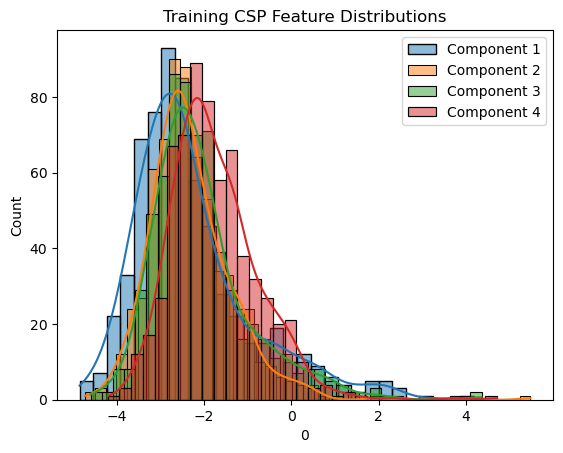

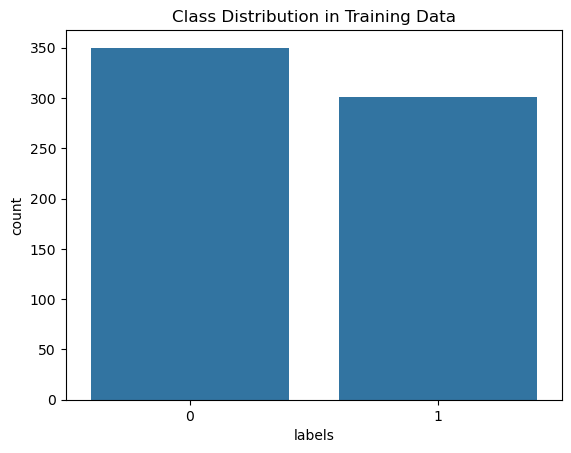

In [4]:
# Check distributions of CSP features
import matplotlib.pyplot as plt
import seaborn as sns

# Plot distributions of CSP components for training data
for i in range(4):  # Assuming 4 CSP components
    sns.histplot(train_df.iloc[:, i], kde=True, label=f"Component {i+1}")
plt.title("Training CSP Feature Distributions")
plt.legend()
plt.show()

# Compare class distributions
sns.countplot(x='labels', data=train_df)
plt.title("Class Distribution in Training Data")
plt.show()


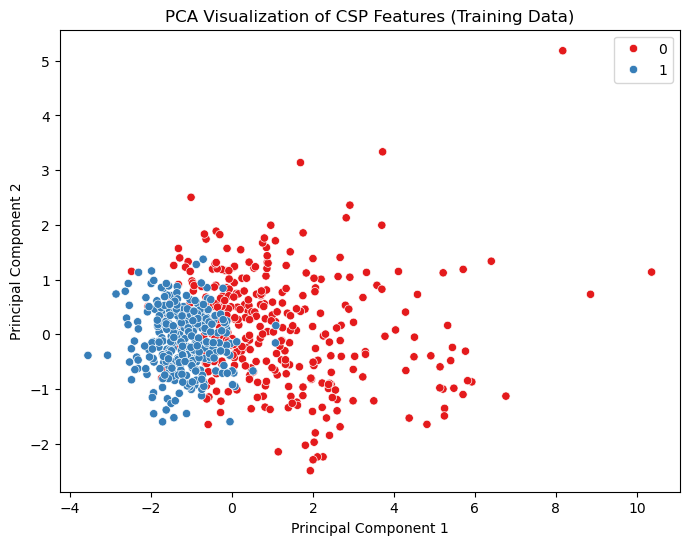

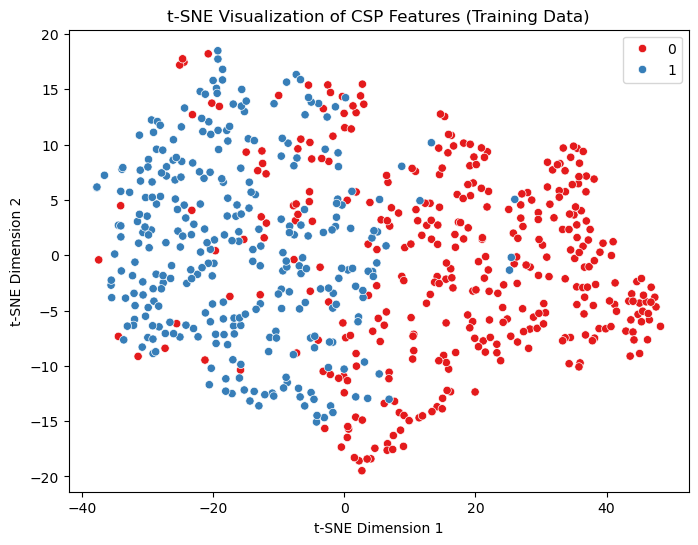

In [5]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Prepare training features and labels
X_train = train_df.iloc[:, :-1].values  # Features (exclude the last 'labels' column)
y_train = train_df['labels'].values  # Labels

# PCA visualization
pca = PCA(n_components=2)
pca_result = pca.fit_transform(X_train)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=pca_result[:, 0], y=pca_result[:, 1], hue=y_train, palette="Set1")
plt.title("PCA Visualization of CSP Features (Training Data)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

# t-SNE visualization
tsne = TSNE(n_components=2, random_state=42)
tsne_result = tsne.fit_transform(X_train)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=tsne_result[:, 0], y=tsne_result[:, 1], hue=y_train, palette="Set1")
plt.title("t-SNE Visualization of CSP Features (Training Data)")
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.show()


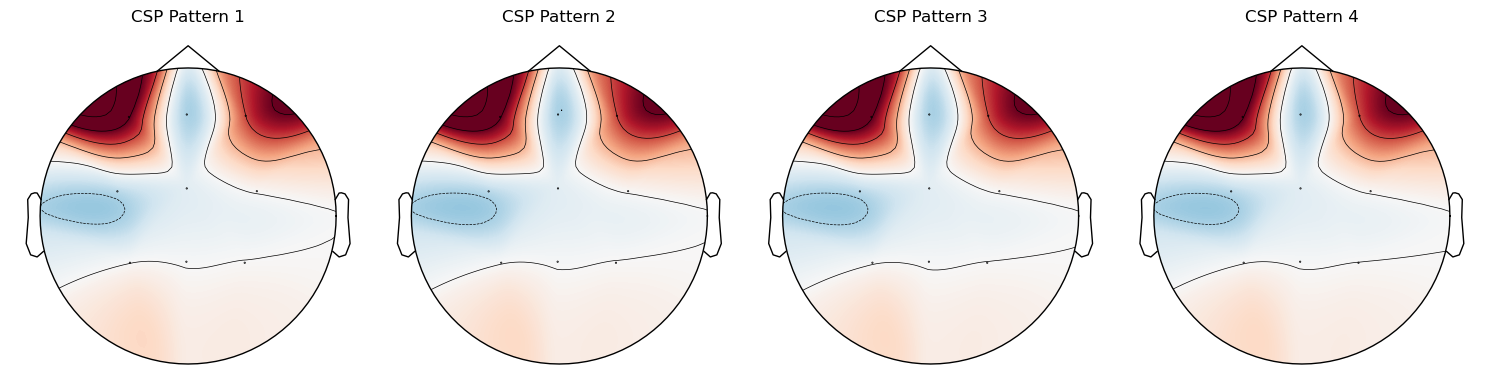

In [6]:
import joblib
import matplotlib.pyplot as plt
from mne import create_info
from mne.channels import make_standard_montage
from mne.viz import plot_topomap

# Load the CSP model
csp_model_path = r"C:\Users\Ferran\Desktop\TFM\TFM_EEG\DATASET\MI\SUB_2\CSP\csp_model.pkl"
csp = joblib.load(csp_model_path)

# Set channel info (must match training configuration)
ch_names = ['F3', 'Fz', 'F4', 'C3', 'Cz', 'C4', 'P3', 'Pz', 'P4']
sfreq = 250  # Sampling frequency used during training
info = create_info(ch_names=ch_names, sfreq=sfreq, ch_types='eeg')

# Attach a standard 10-20 montage to provide electrode positions
montage = make_standard_montage('standard_1020')
info.set_montage(montage)

# Select patterns corresponding to the 10 channels used during training
patterns_to_plot = csp.patterns_[:len(ch_names), :]

# Plot spatial patterns
fig, axes = plt.subplots(1, 4, figsize=(15, 5))  # Adjust for the number of components (e.g., 4)
for i, ax in enumerate(axes):
    plot_topomap(patterns_to_plot[:, i], info, axes=ax, show=False)
    ax.set_title(f"CSP Pattern {i+1}")
plt.tight_layout()
plt.show()


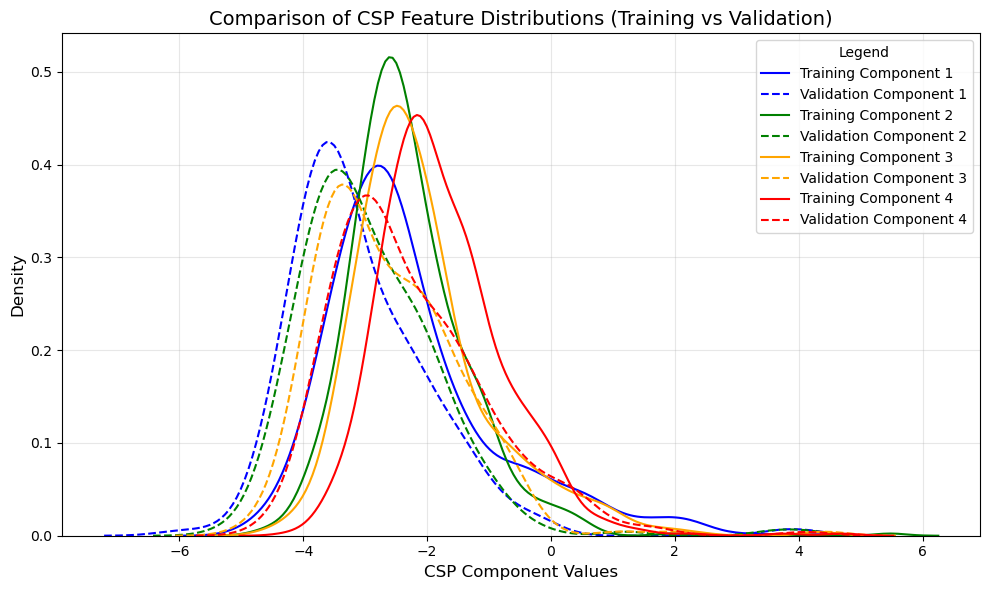

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

# Define colors for training and validation components
colors = ['blue', 'green', 'orange', 'red']  # Adjust colors as needed

# Compare distributions of CSP components between training and validation
plt.figure(figsize=(10, 6))
for i in range(4):  # Assuming 4 components
    sns.kdeplot(
        train_df.iloc[:, i], 
        color=colors[i], 
        label=f"Training Component {i+1}", 
        linestyle='-'
    )
    sns.kdeplot(
        val_df.iloc[:, i], 
        color=colors[i], 
        label=f"Validation Component {i+1}", 
        linestyle='--'
    )
plt.title("Comparison of CSP Feature Distributions (Training vs Validation)", fontsize=14)
plt.xlabel("CSP Component Values", fontsize=12)
plt.ylabel("Density", fontsize=12)
plt.legend(title="Legend", fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


<div class="alert alert-info" role="alert", style="border-radius: 70px">
    <h2 style="text-align: center; margin-top:0.5cm; margin-bottom:0.5cm; font-size:20px">Data loading</h2>
</div>


In [8]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN, OPTICS
from sklearn.cluster import MeanShift, estimate_bandwidth
from sklearn.mixture import GaussianMixture
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.metrics import davies_bouldin_score, adjusted_mutual_info_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from yellowbrick.cluster import KElbowVisualizer, SilhouetteVisualizer
from pathlib import Path
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing import StandardScaler

from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score

import joblib

In [9]:
file_path = r"C:\Users\Ferran\Desktop\TFM\TFM_EEG\DATASET\MI\SUB_2\CSP\csp_features_labels.parquet"
# file_path = r"C:\Users\Ferran\Desktop\TFM\TFM_EEG\DATASET\MI\SUB_2\CSP\Test_v2\csp_features_labels.parquet"
# Load the Parquet file
data = pd.read_parquet(file_path)

# Display the first few rows of the DataFrame
data


,0,1,2,3,labels
0,-2.250265,-3.197191,-2.120102,-1.253858,0
1,-2.474475,-1.047509,-2.057953,-0.780182,0
2,-3.593848,-2.961035,-2.236238,-1.268460,0
3,-3.462869,-2.375898,-0.988663,-1.428627,0
4,-3.141334,-2.768838,-0.713592,-1.142243,0
...,...,...,...,...,...
646,-2.524649,-2.303035,-2.765983,-3.459513,1
647,-2.341928,-3.077011,-3.032143,-1.992895,1
648,-1.823746,-2.565983,-2.533202,-1.993773,1
649,-2.538709,-3.674447,-2.235387,-2.075693,1


In [10]:
# ADDED CODE WHEN WORKING WITH 4 FEATURES

# Combine features into a single column
data['features'] = data[['0', '1', '2', '3']].values.tolist()

# Drop the individual feature columns
data.drop(columns=['0', '1', '2', '3'], inplace=True)

# Reorder columns so 'features' comes before 'labels'
data = data[['features', 'labels']]

# Check the resulting DataFrame
print(data.head())


                                            features  labels
0  [-2.250265318832594, -3.1971913387863973, -2.1...       0
1  [-2.4744754938027644, -1.047509196086504, -2.0...       0
2  [-3.5938479311874705, -2.961035415128572, -2.2...       0
3  [-3.4628689450534704, -2.3758979635543964, -0....       0
4  [-3.1413344337031557, -2.768838148513806, -0.7...       0


In [11]:
# Flatten and handle inconsistent lengths
# Assume the features are 2D or nested; we need to flatten them
X = [np.ravel(feature) for feature in data['features']]


# Find the maximum length of the flattened features
max_length = max(len(x) for x in X)

# Pad all feature arrays to the maximum length
X_padded = np.array([np.pad(x, (0, max_length - len(x)), mode='constant') for x in X])

# Extract labels
y = data['labels']


In [12]:
# Flatten each nested array within X_padded
X_flattened = np.array([np.hstack(sample) for sample in X_padded])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_flattened)

print("Normalized features shape:", X_scaled.shape)

Normalized features shape: (651, 4)


In [13]:

print("Shape of X_flattened:", X_flattened.shape)
print("Example flattened element:", X_flattened[0])

print("Shape of X_scaled:", X_scaled.shape)
print("Example normalized element:", X_scaled[0])


Shape of X_flattened: (651, 4)
Example flattened element: [-2.25026532 -3.19719134 -2.12010247 -1.25385762]
Shape of X_scaled: (651, 4)
Example normalized element: [ 0.021211   -0.93201059 -0.04172383  0.49819839]


<div class="alert alert-info" role="alert", style="border-radius: 70px">
    <h2 style="text-align: center; margin-top:0.5cm; margin-bottom:0.5cm; font-size:20px">Training</h2>
</div>


In [14]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn import metrics
from sklearn.preprocessing import StandardScaler
from sklearn.impute import KNNImputer
from pathlib import Path
from sklearn.impute import SimpleImputer
from yellowbrick.model_selection import ValidationCurve, LearningCurve, validation_curve
from yellowbrick.classifier import confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder
import pandas as pd

In [15]:
# Split the data
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.4, random_state=42)

In [16]:
from yellowbrick.model_selection import ValidationCurve, LearningCurve
from yellowbrick.classifier import ConfusionMatrix
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
    classification_report
)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

def evaluate_model_train(
    model, 
    X_train, 
    y_train, 
    X_test, 
    y_test, 
    label_encoder=None, 
    model_name="Model", 
    param_name=None, 
    param_range=None
):
    """
    Comprehensive evaluation of a classification model during training, including:
    - Validation curve
    - Learning curve
    - Metrics evaluation
    - Confusion matrix for training and validation
    - ROC curve for both training and validation
    - Classification report heatmap

    Returns:
    - metrics: A dictionary with evaluation metrics for training and validation.
    """
    # Validation Curve
    if param_name and param_range is not None:
        print(f"Studying hyperparameter: {param_name}")
        vc = ValidationCurve(
            model, param_name=param_name,
            param_range=param_range, cv=10, scoring="f1_weighted", n_jobs=-1
        )
        vc.fit(X_train, y_train)
        vc.show()
    
    # Learning Curve
    print("Generating learning curve...")
    sizes = np.linspace(0.1, 1.0, 10)  # Train sizes for learning curve
    lc = LearningCurve(
        model, cv=10, scoring='f1_weighted', train_sizes=sizes, n_jobs=-1
    )
    lc.fit(X_train, y_train)
    lc.show()

    # Train the model
    model.fit(X_train, y_train)

    # Predict probabilities for training and validation
    y_train_pred_proba = (
        model.predict_proba(X_train)[:, 1]
        if hasattr(model, "predict_proba")
        else None
    )
    y_test_pred_proba = (
        model.predict_proba(X_test)[:, 1]
        if hasattr(model, "predict_proba")
        else None
    )

    # Calculate ROC and AUC for training
    if y_train_pred_proba is not None:
        fpr_train, tpr_train, _ = roc_curve(y_train, y_train_pred_proba)
        roc_auc_train = roc_auc_score(y_train, y_train_pred_proba)
    else:
        fpr_train, tpr_train, roc_auc_train = None, None, None

    # Calculate ROC and AUC for validation
    if y_test_pred_proba is not None:
        fpr_test, tpr_test, _ = roc_curve(y_test, y_test_pred_proba)
        roc_auc_test = roc_auc_score(y_test, y_test_pred_proba)
    else:
        fpr_test, tpr_test, roc_auc_test = None, None, None

    # Metrics for validation
    accuracy = accuracy_score(y_test, model.predict(X_test))
    precision = precision_score(y_test, model.predict(X_test), zero_division=0)
    recall = recall_score(y_test, model.predict(X_test), zero_division=0)

    # Confusion Matrix for validation
    cm = ConfusionMatrix(model, classes=["Negative", "Positive"], cmap="Blues")
    cm.fit(X_train, y_train)
    cm.score(X_test, y_test)
    cm.show()

    # Classification Report Heatmap for validation
    report = classification_report(y_test, model.predict(X_test), output_dict=True)
    report_df = pd.DataFrame(report).transpose()

    plt.figure(figsize=(10, 6))
    sns.heatmap(report_df.iloc[:-1, :-1], annot=True, cmap="YlGn", fmt=".2f", cbar=True)
    plt.title(f"{model_name} Classification Report")
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    plt.show()

    # ROC Curve for validation
    if y_test_pred_proba is not None:
        plt.figure(figsize=(8, 6))
        plt.plot(fpr_test, tpr_test, label=f"Validation ROC Curve (AUC = {roc_auc_test:.4f})")
        plt.plot([0, 1], [0, 1], linestyle="--", color="red")
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title(f"{model_name} Validation ROC Curve")
        plt.legend(loc="best")
        plt.grid()
        plt.show()

    metrics = {
        # Validation metrics
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "roc_auc": roc_auc_test,
        "fpr_test": fpr_test,
        "tpr_test": tpr_test,
        # Training metrics
        "fpr_train": fpr_train,
        "tpr_train": tpr_train,
        "roc_auc_train": roc_auc_train,
    }

    return metrics


## LDA

The first classifier used is the **Linear Discriminant Analysis (LDA)**. This method projects high-dimensional data onto a lower-dimensional space with good-class separability. It assumes that different classes generate data based on Gaussian distributions with a shared covariance matrix. LDA aims to find a linear combination of features that best separates the classes, making it useful for dimensionality reduction and as a classifier for supervised learning tasks.

Studying hyperparameter: shrinkage


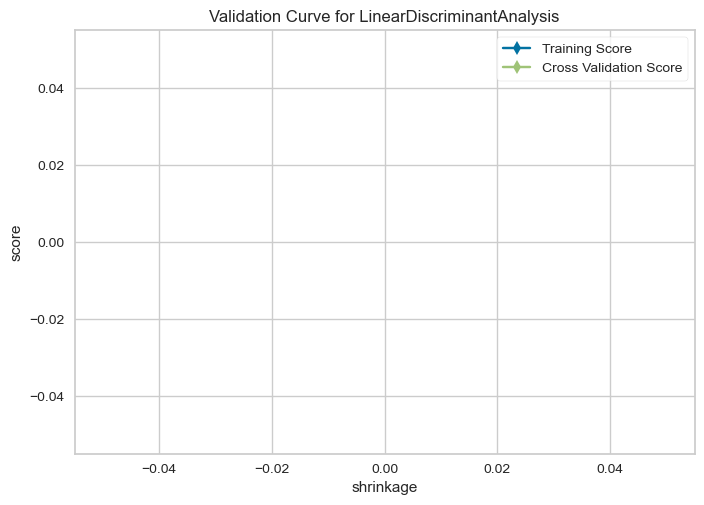

Generating learning curve...


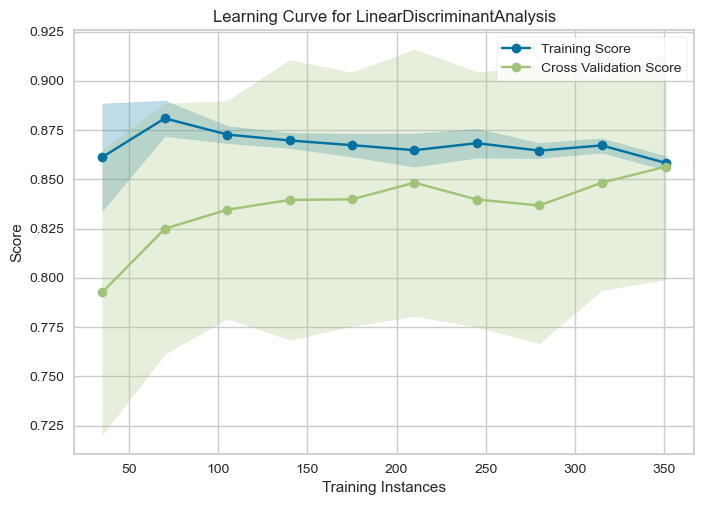

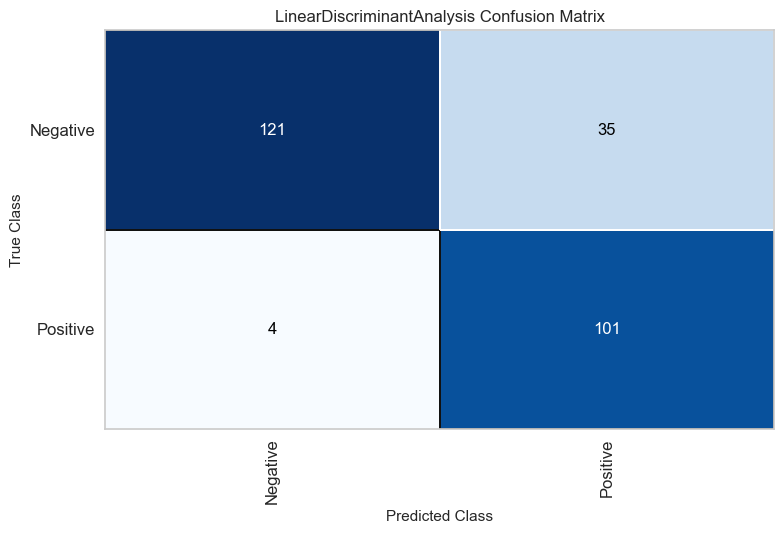

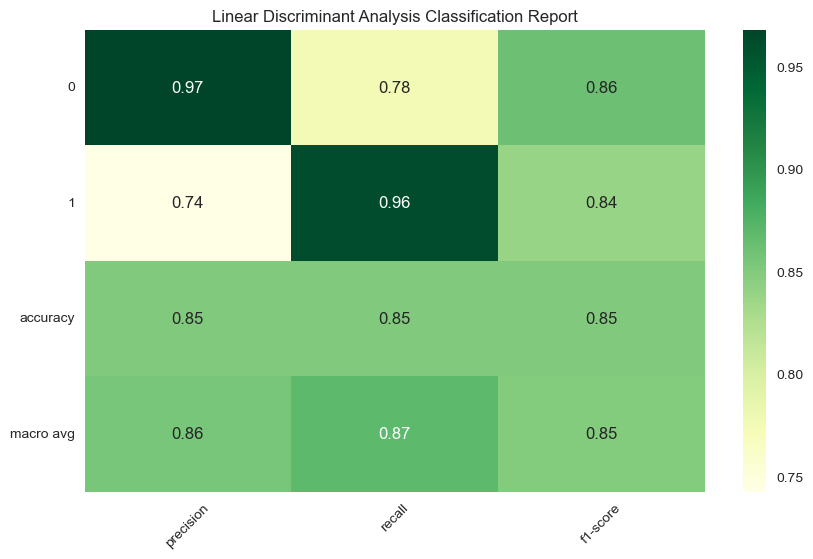

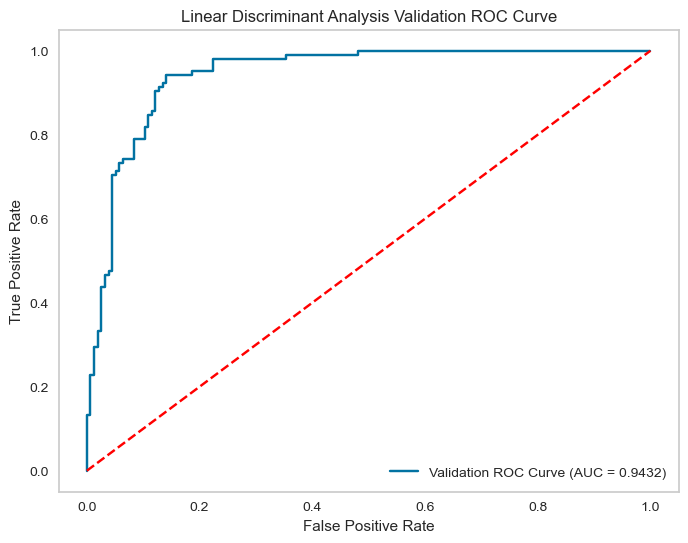

In [17]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# Initialize the LDA model
lda_model = LinearDiscriminantAnalysis()

# Define the range of hyperparameters for validation curve
shrinkage_range = np.linspace(0.1, 1.0, 20)

# Evaluate the model during training
lda_training_metrics = evaluate_model_train(
    model=lda_model,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    model_name="Linear Discriminant Analysis",
    param_name="shrinkage",
    param_range=shrinkage_range
)

# Extract training ROC details
fpr_lda_train = lda_training_metrics["fpr_train"]
tpr_lda_train = lda_training_metrics["tpr_train"]
roc_auc_lda_train = lda_training_metrics["roc_auc_train"]

# Extract validation ROC details
fpr_lda = lda_training_metrics["fpr_test"]
tpr_lda = lda_training_metrics["tpr_test"]
roc_auc_lda = lda_training_metrics["roc_auc"]


## Support Vector Machine

The following method used is the Support Vector Machine (SVM). This supervised learning algorithm finds the hyperplane that best separates data into classes by maximizing the margin between classes. It can handle high-dimensional data and is effective in cases with clear margin separation

Studying hyperparameter: C


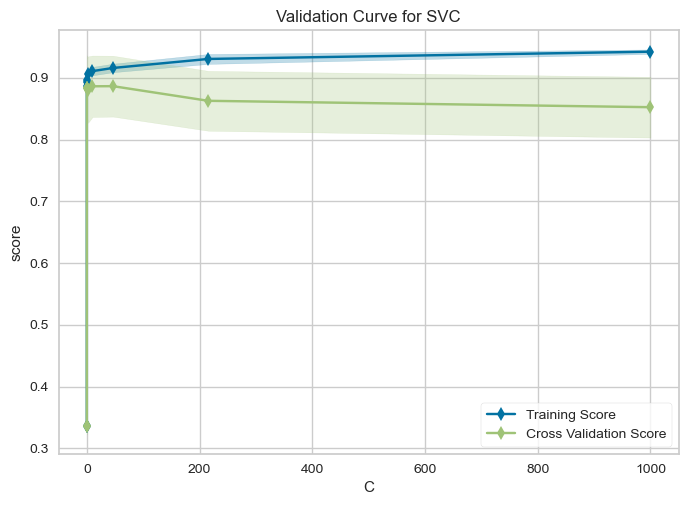

Generating learning curve...


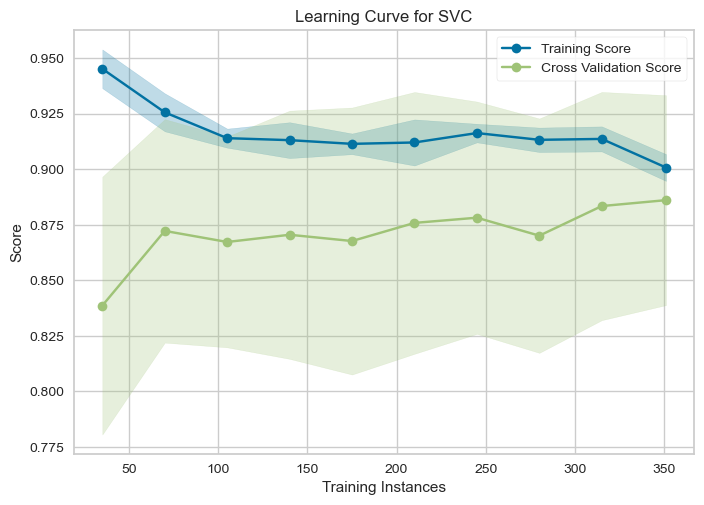

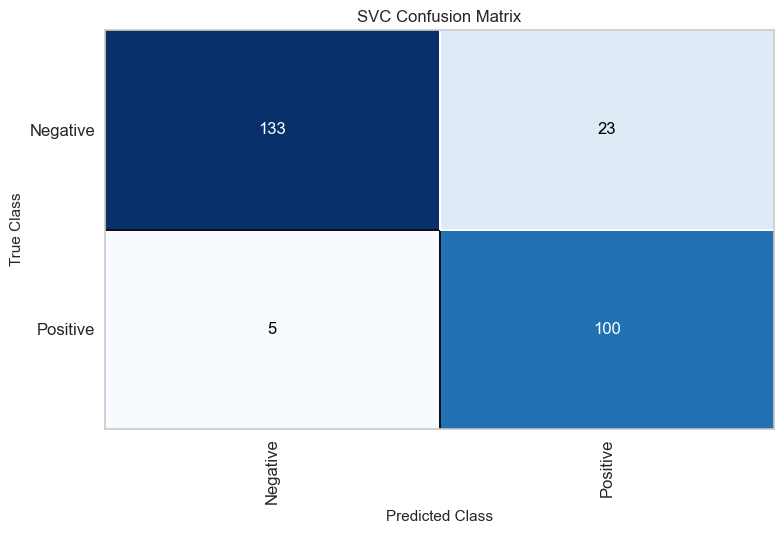

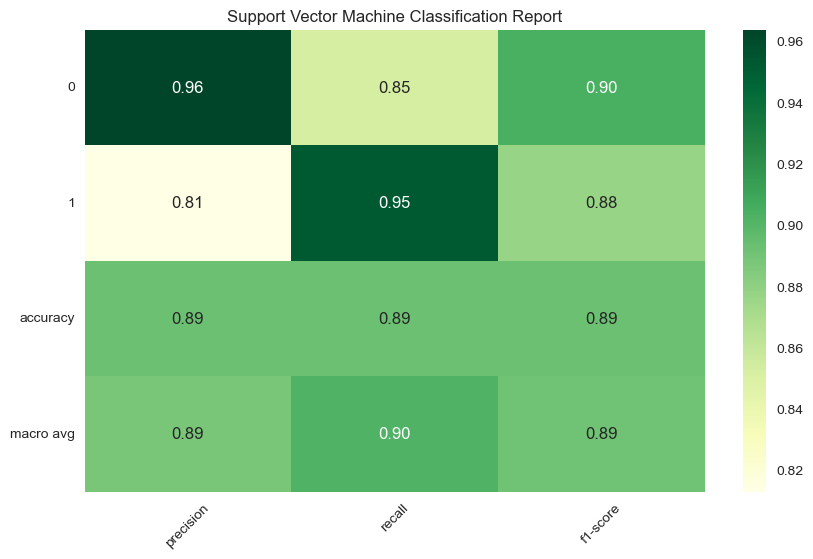

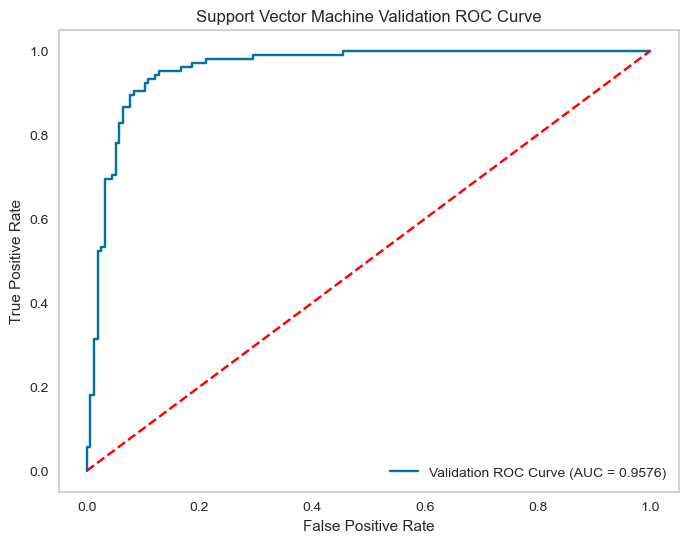

In [18]:
from sklearn.svm import SVC

# Initialize the SVM model
svm_model = SVC(kernel='rbf', probability=True, random_state=42)

# Define the range of hyperparameters for validation curve
C_range = np.logspace(-3, 3, 10)

# Evaluate the SVM model
svm_training_metrics = evaluate_model_train(
    model=svm_model,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    model_name="Support Vector Machine",
    param_name="C",
    param_range=C_range
)

# Extract training ROC details
fpr_svm_train = svm_training_metrics["fpr_train"]
tpr_svm_train = svm_training_metrics["tpr_train"]
roc_auc_svm_train = svm_training_metrics["roc_auc_train"]

# Extract validation ROC details
fpr_svm = svm_training_metrics["fpr_test"]
tpr_svm = svm_training_metrics["tpr_test"]
roc_auc_svm = svm_training_metrics["roc_auc"]


### **Decision Tree**

Studying hyperparameter: max_depth


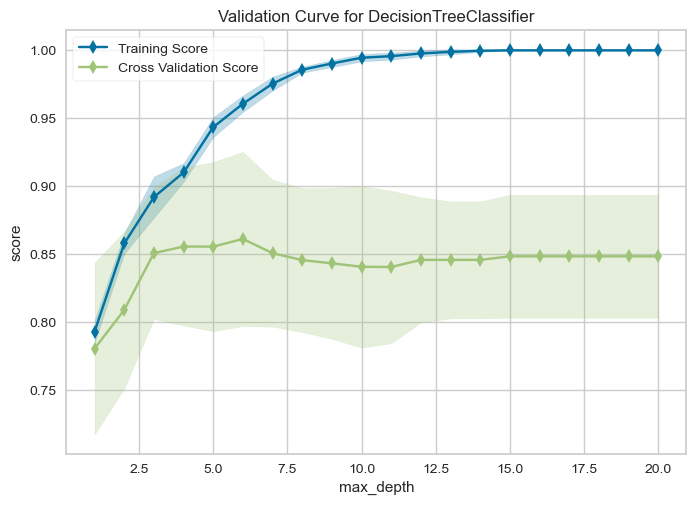

Generating learning curve...


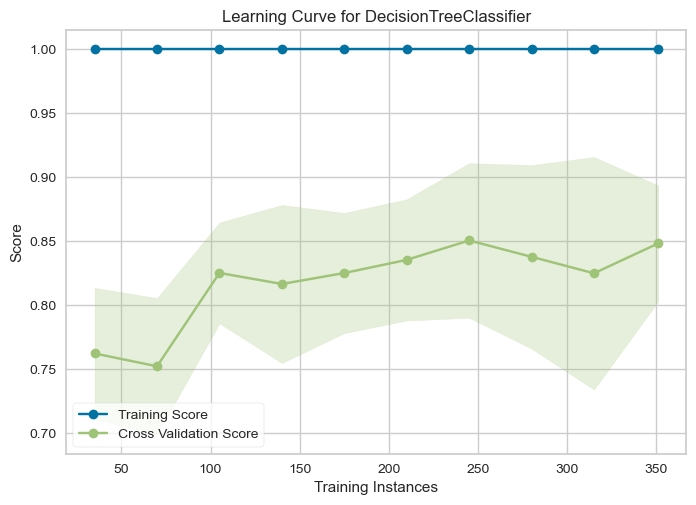

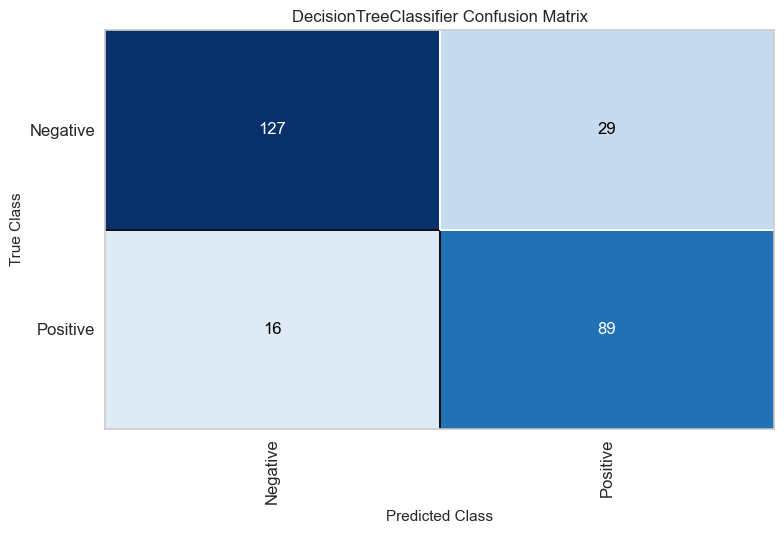

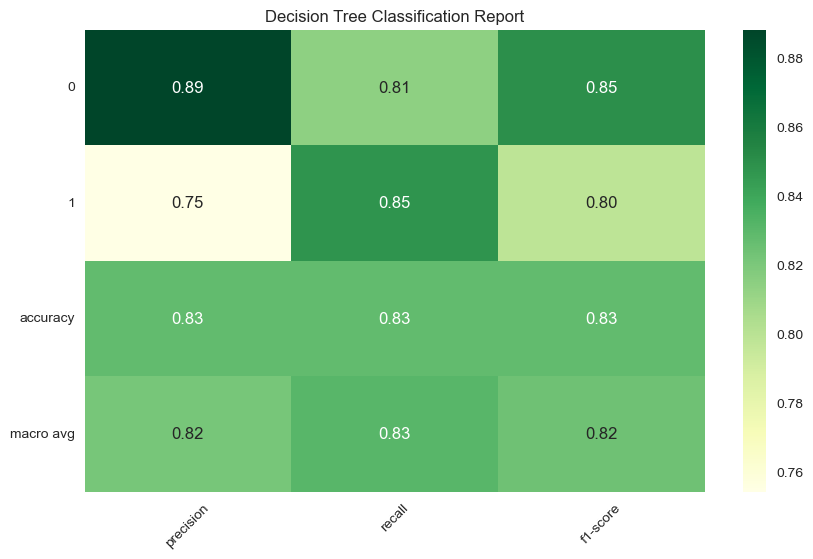

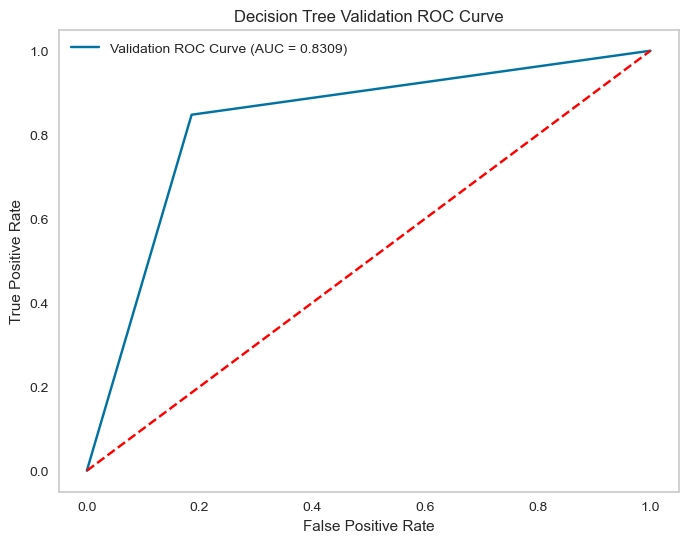

In [19]:
# Decision Tree Classifier
from sklearn.tree import DecisionTreeClassifier

# Initialize and evaluate Decision Tree
dt_model = DecisionTreeClassifier(random_state=42)

# Define the range for the 'max_depth' parameter
max_depth_range = np.arange(1, 21)

# Evaluate Decision Tree
dt_training_metrics = evaluate_model_train(
    model=dt_model,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    model_name="Decision Tree",
    param_name="max_depth",
    param_range=max_depth_range
)

# Extract training ROC details
fpr_dt_train = dt_training_metrics["fpr_train"]
tpr_dt_train = dt_training_metrics["tpr_train"]
roc_auc_dt_train = dt_training_metrics["roc_auc_train"]

# Extract validation ROC details
fpr_dt = dt_training_metrics["fpr_test"]
tpr_dt = dt_training_metrics["tpr_test"]
roc_auc_dt = dt_training_metrics["roc_auc"]


## KNN

Studying hyperparameter: n_neighbors


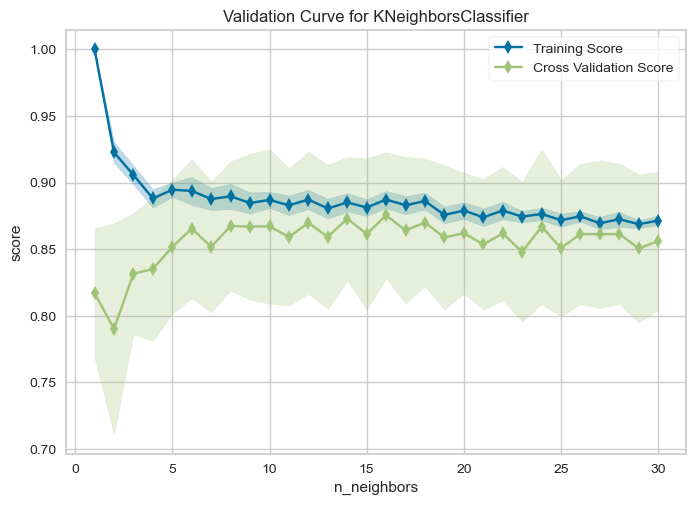

Generating learning curve...


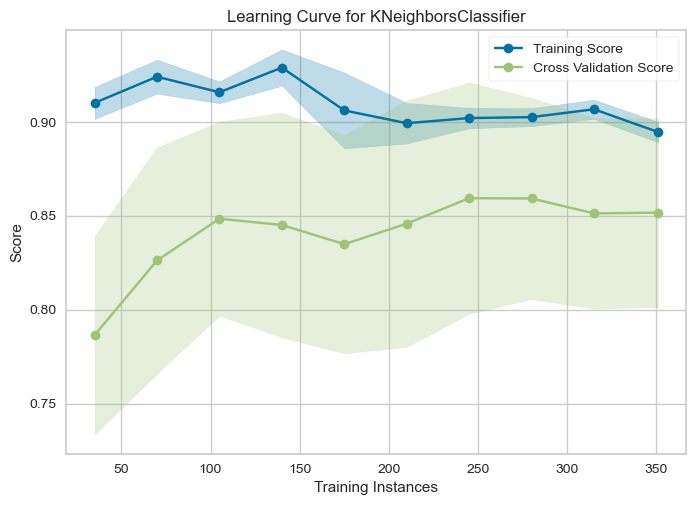

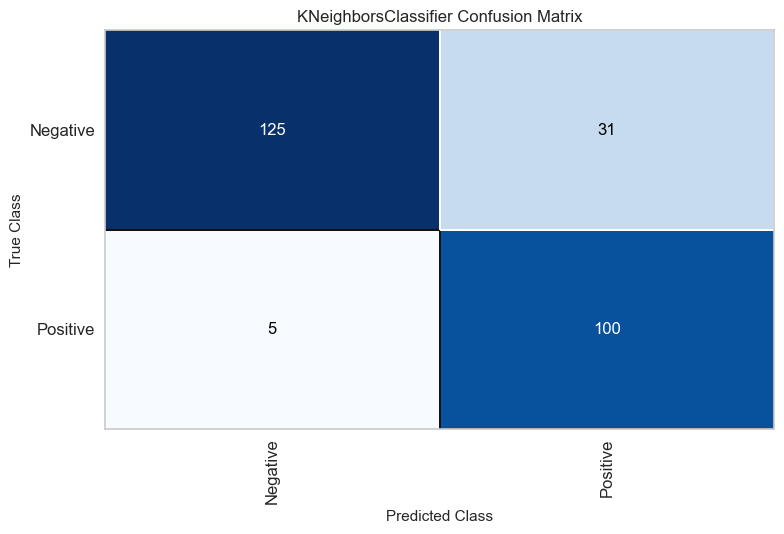

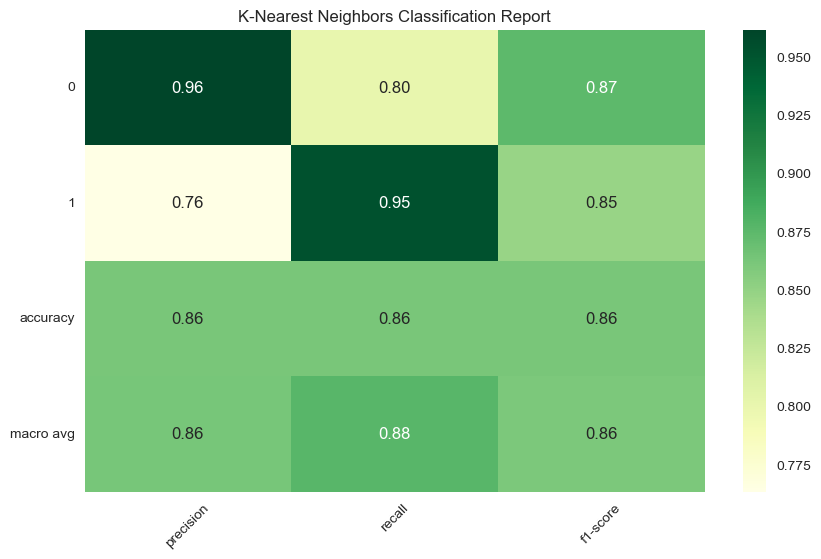

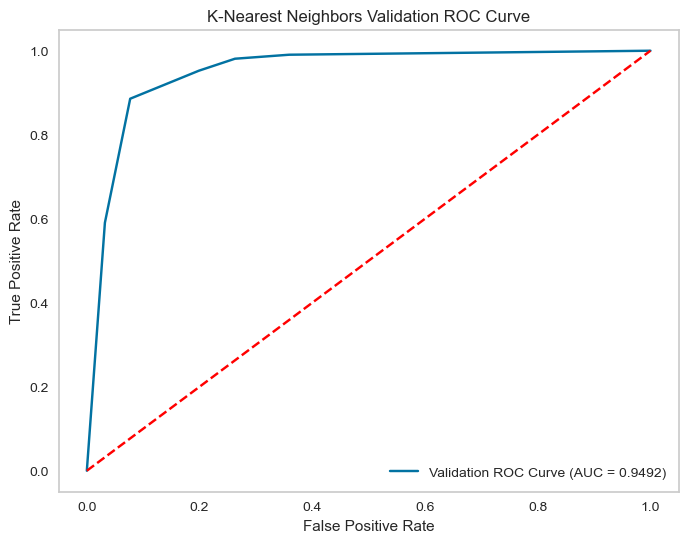

In [20]:
# K-Nearest Neighbors Classifier
from sklearn.neighbors import KNeighborsClassifier

# Initialize and evaluate KNN
knn_model = KNeighborsClassifier()

# Define the range for the 'n_neighbors' parameter
n_neighbors_range = np.arange(1, 31)

# Evaluate KNN
knn_training_metrics = evaluate_model_train(
    model=knn_model,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    model_name="K-Nearest Neighbors",
    param_name="n_neighbors",
    param_range=n_neighbors_range
)

# Extract training ROC details
fpr_knn_train = knn_training_metrics["fpr_train"]
tpr_knn_train = knn_training_metrics["tpr_train"]
roc_auc_knn_train = knn_training_metrics["roc_auc_train"]

# Extract validation ROC details
fpr_knn = knn_training_metrics["fpr_test"]
tpr_knn = knn_training_metrics["tpr_test"]
roc_auc_knn = knn_training_metrics["roc_auc"]


<div class="alert alert-info" role="alert", style="border-radius: 70px">
    <h2 style="text-align: center; margin-top:0.5cm; margin-bottom:0.5cm; font-size:20px">Validation</h2>
</div>


In [21]:
# Load the Parquet file
# validation_path = r"C:\Users\Ferran\Desktop\TFM\TFM_EEG\DATASET\MI\SUB_2\CSP\Validation\csp_features_labels_validation.parquet"
validation_path = r"C:\Users\Ferran\Desktop\TFM\TFM_EEG\DATASET\MI\SUB_2\CSP\Validation_test\csp_features_labels_validation.parquet"
validation_data = pd.read_parquet(validation_path)

# Display the first few rows of the DataFrame
validation_data

,0,1,2,3,labels
0,-3.315264,-1.842860,-3.703404,-3.474552,0
1,-2.021105,-0.901401,-3.422205,-3.905316,0
2,-1.380460,-2.607968,-3.402572,-3.340552,0
3,-3.399149,-2.118043,-3.199128,-3.383165,0
4,-2.264250,-1.154802,-3.310987,-2.780178,0
...,...,...,...,...,...
235,-3.554519,-3.159049,-1.771760,-1.575974,1
236,-4.398436,-4.478777,-0.555702,-1.300987,1
237,-3.981576,-3.329080,-0.926834,-0.580407,1
238,-4.450248,-2.938428,-2.465475,-2.770043,1


In [22]:
# Count the occurrences of each value in the 'side' column
side_counts = validation_data['labels'].value_counts()

print("Counts of rows for each side:")
print(side_counts)

Counts of rows for each side:
labels
0    120
1    120
Name: count, dtype: int64


There are the same number of instances of right and left, this means that the validation dataset is equilibrated

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    roc_curve,
)
import seaborn as sns

def evaluate_model(model, X, y, label_encoder=None, model_name="Model"):
    """
    Evaluates and visualizes the performance of a classification model.

    Parameters:
    - model: A pre-trained scikit-learn compatible classification model.
    - X: Preprocessed feature matrix (e.g., scaled and imputed).
    - y: Target vector (Pandas Series or NumPy array).
    - label_encoder: An optional LabelEncoder object for decoding labels. Required for visualization.
    - model_name: A string representing the name of the model (e.g., "KNN", "Decision Tree").

    Returns:
    - metrics: A dictionary containing evaluation metrics (accuracy, precision, recall, roc_auc, fpr, tpr).
    """
    # Predict on the dataset
    y_pred = model.predict(X)
    y_pred_proba = (
        model.predict_proba(X)[:, 1]
        if hasattr(model, "predict_proba")
        else model.decision_function(X)
        if hasattr(model, "decision_function")
        else None
    )

    # Calculate metrics
    accuracy = accuracy_score(y, y_pred)
    precision = precision_score(y, y_pred, zero_division=0)
    recall = recall_score(y, y_pred, zero_division=0)
    roc_auc = roc_auc_score(y, y_pred_proba) if y_pred_proba is not None else None

    # Calculate FPR and TPR for the ROC curve (if applicable)
    fpr, tpr, thresholds = (roc_curve(y, y_pred_proba) if y_pred_proba is not None else (None, None, None))

    metrics = {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "roc_auc": roc_auc,
        "fpr": fpr,
        "tpr": tpr,
    }

    # Print metrics
    print(f"\n{model_name} Evaluation Metrics:")
    for key, value in metrics.items():
        if key in ["fpr", "tpr"]:  # Skip printing FPR and TPR as they are arrays
            continue
        print(f"{key.capitalize()}: {value:.4f}" if value is not None else f"{key.capitalize()}: N/A")

    # Confusion Matrix
    cm = confusion_matrix(y, y_pred)
    cm_display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_ if label_encoder else None)
    cm_display.plot(cmap="Blues")
    plt.title(f"{model_name} Confusion Matrix")
    plt.show()

    # Classification Report Heatmap
    report = classification_report(y, y_pred, output_dict=True)
    report_df = pd.DataFrame(report).transpose()

    plt.figure(figsize=(10, 6))
    sns.heatmap(report_df.iloc[:-1, :-1], annot=True, cmap="YlGn", fmt=".2f", cbar=True)
    plt.title(f"{model_name} Classification Report")
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    plt.show()

    # ROC Curve (if applicable)
    if y_pred_proba is not None:
        plt.figure(figsize=(8, 6))
        plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.4f})")
        plt.plot([0, 1], [0, 1], linestyle="--", color="red")
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title(f"{model_name} ROC Curve")
        plt.legend(loc="best")
        plt.grid()
        plt.show()

    return metrics


In [24]:
# ADDED CODE WHEN WORKING WITH 4 FEATURES

# Combine features into a single column
validation_data['features'] = validation_data[['0', '1', '2', '3']].values.tolist()

# Drop the individual feature columns
validation_data.drop(columns=['0', '1', '2', '3'], inplace=True)

# Reorder columns so 'features' comes before 'labels'
validation_data = validation_data[['features', 'labels']]

# Check the resulting DataFrame
print(validation_data.head())


                                            features  labels
0  [-3.315264148474101, -1.842860248827048, -3.70...       0
1  [-2.0211048268475746, -0.9014008513823994, -3....       0
2  [-1.3804598301554856, -2.6079676931962537, -3....       0
3  [-3.399149459984842, -2.1180429687715137, -3.1...       0
4  [-2.2642497607341037, -1.154802385828275, -3.3...       0


In [25]:
# Flatten and handle inconsistent lengths
# Assume the features are 2D or nested; we need to flatten them
X_val = [np.ravel(feature) for feature in validation_data['features']]

# Find the maximum length of the flattened features
max_length_val = max(len(x) for x in X_val)

# Pad all feature arrays to the maximum length
X_padded_val = np.array([np.pad(x, (0, max_length_val - len(x)), mode='constant') for x in X_val])

# Extract labels and encode
y = validation_data['labels']
label_encoder = LabelEncoder()
y_validation_encoded = label_encoder.fit_transform(y)

# Flatten each nested array within X_padded
X_flattened_val = np.array([np.hstack(sample) for sample in X_padded_val])

# Use the scaler from training to transform validation data
X_scaled_val = scaler.transform(X_flattened_val)
print("Normalized features shape:", X_scaled_val.shape)

Normalized features shape: (240, 4)


## Linear Discriminant Analysis


Linear Discriminant Analysis Evaluation Metrics:
Accuracy: 0.3875
Precision: 0.4341
Recall: 0.7417
Roc_auc: 0.1785


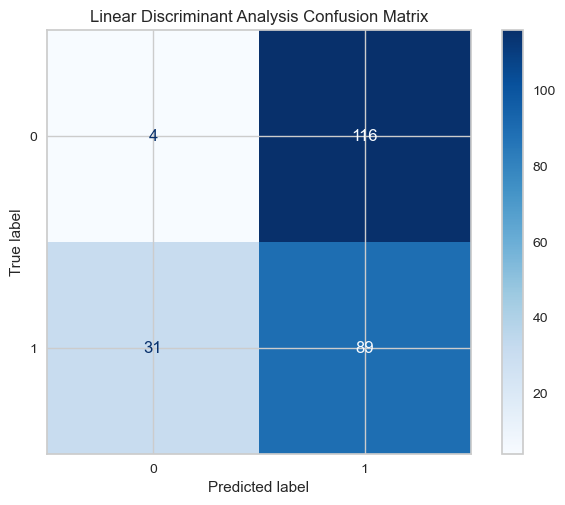

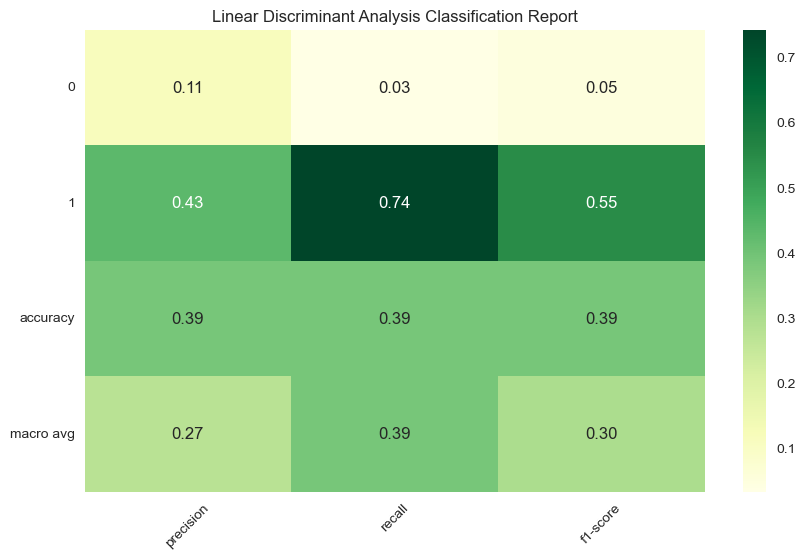

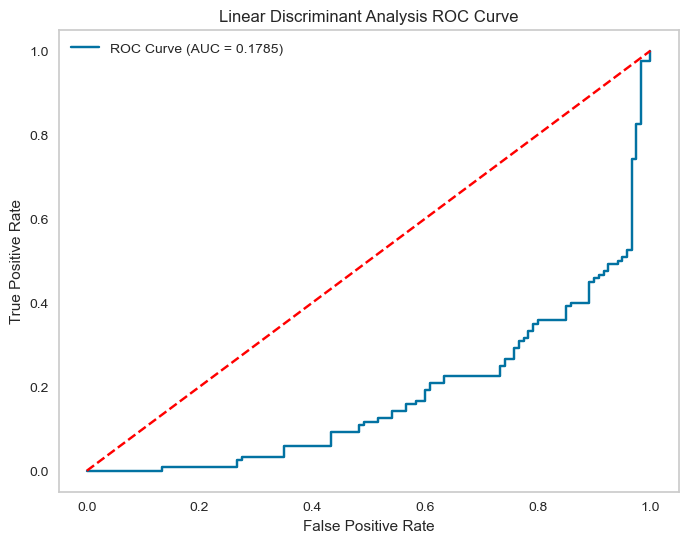

In [26]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# Linear Discriminant Analysis Classifier
lda = LinearDiscriminantAnalysis()  # You can adjust parameters if needed
lda.fit(X_train, y_train)

# Evaluate LDA
lda_metrics = evaluate_model(
    model=lda,
    X=X_scaled_val,
    y=y_validation_encoded,
    label_encoder=label_encoder,
    model_name="Linear Discriminant Analysis"
)

accuracy_lda = lda_metrics["accuracy"]
precision_lda = lda_metrics["precision"]
recall_lda = lda_metrics["recall"]
roc_auc_lda = lda_metrics["roc_auc"]
fpr_lda, tpr_lda = lda_metrics["fpr"], lda_metrics["tpr"]


## Support Vector Machine


Support Vector Machine Evaluation Metrics:
Accuracy: 0.2875
Precision: 0.3191
Recall: 0.3750
Roc_auc: 0.2235


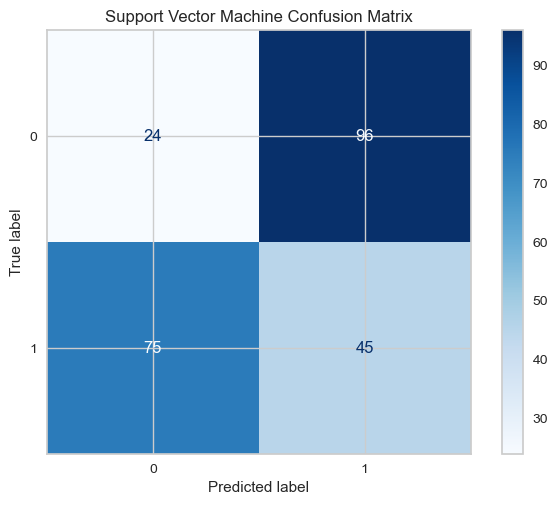

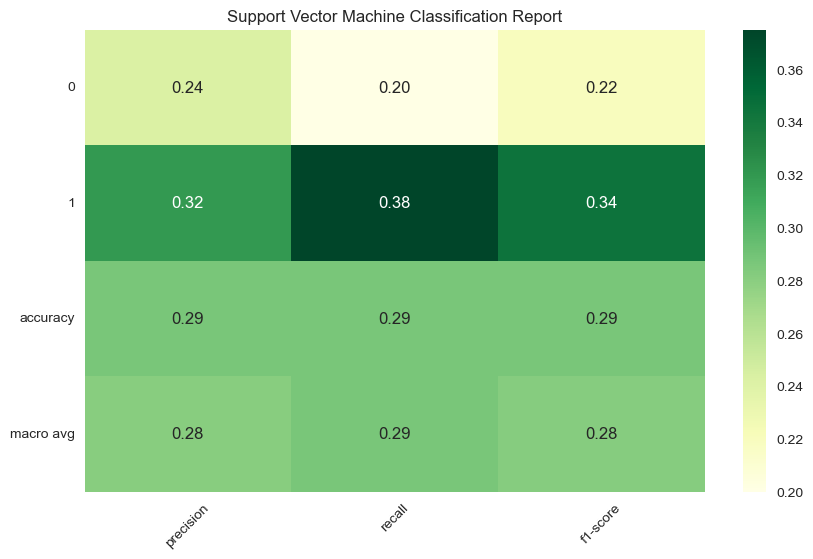

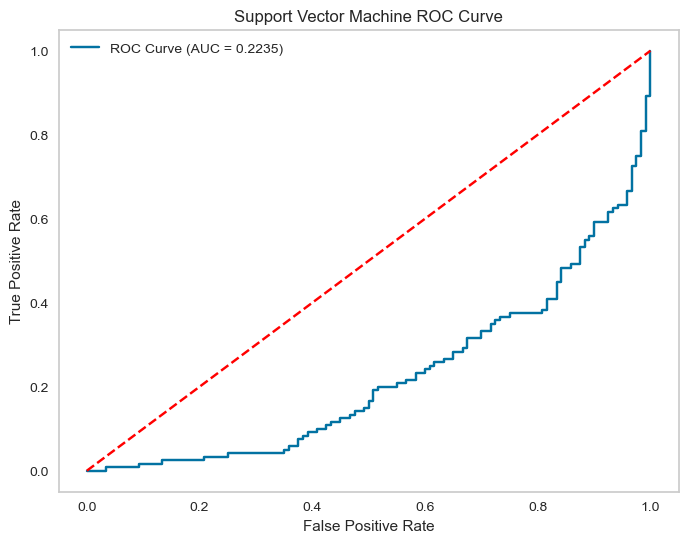

In [27]:
from sklearn.svm import SVC

svm_clf = SVC(probability=True, kernel='rbf', C=1.0, random_state=42)  # Adjust hyperparameters as needed
svm_clf.fit(X_train, y_train)

#Evaluate Support Vector Machine

svm_metrics = evaluate_model(
model=svm_clf,
X=X_scaled_val,
y=y_validation_encoded,
label_encoder=label_encoder,
model_name="Support Vector Machine"
)

accuracy_svm = svm_metrics["accuracy"]
precision_svm = svm_metrics["precision"]
recall_svm = svm_metrics["recall"]
roc_auc_svm = svm_metrics["roc_auc"]
fpr_svm, tpr_svm = svm_metrics["fpr"], svm_metrics["tpr"]

## DECISION TREE


Decision Tree Evaluation Metrics:
Accuracy: 0.4292
Precision: 0.4351
Recall: 0.4750
Roc_auc: 0.4292


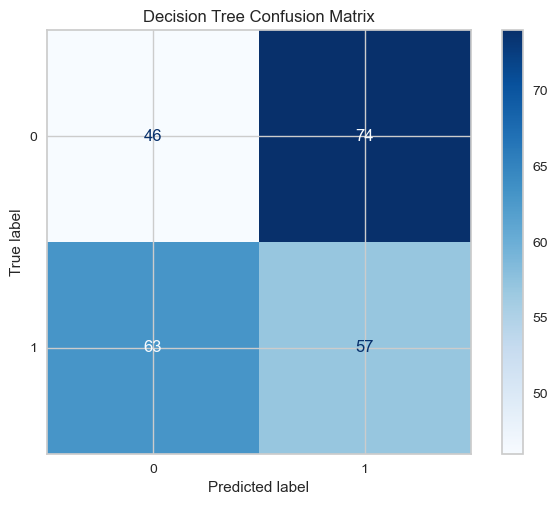

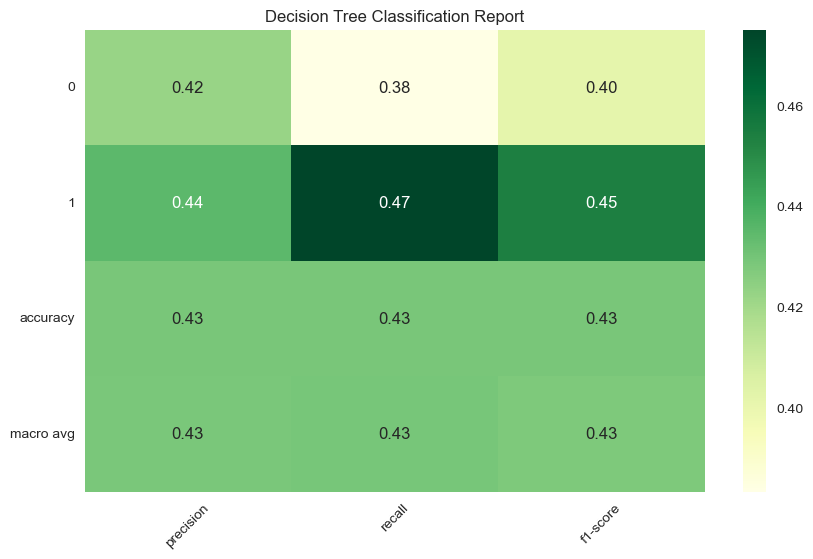

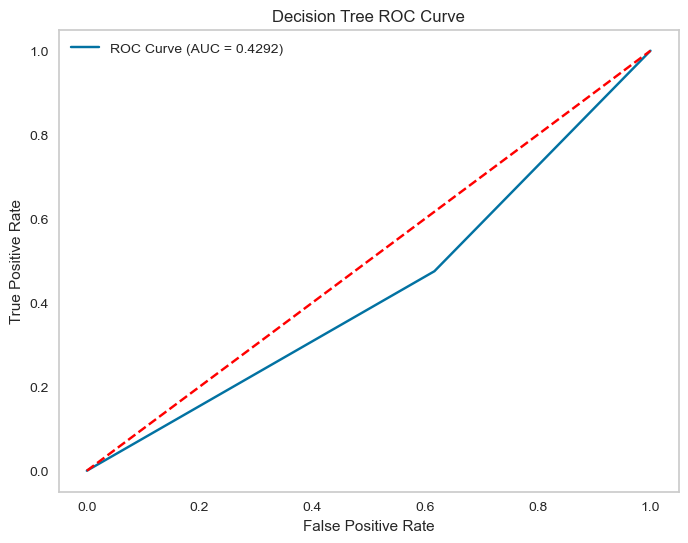

In [28]:
from sklearn.tree import DecisionTreeClassifier

# Decision Tree Classifier
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

# Evaluate Decision Tree
dt_metrics = evaluate_model(
    model=dt,
    X=X_scaled_val,
    y=y_validation_encoded,
    label_encoder=label_encoder,
    model_name="Decision Tree"
)

accuracy_dt = dt_metrics["accuracy"]
precision_dt = dt_metrics["precision"]
recall_dt = dt_metrics["recall"]
roc_auc_dt = dt_metrics["roc_auc"]
fpr_dt, tpr_dt = dt_metrics["fpr"], dt_metrics["tpr"]


## KNN


K-Nearest Neighbors Evaluation Metrics:
Accuracy: 0.3458
Precision: 0.3943
Recall: 0.5750
Roc_auc: 0.3648


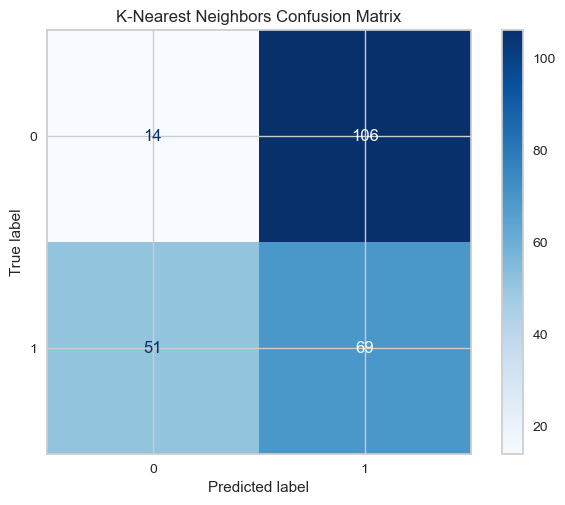

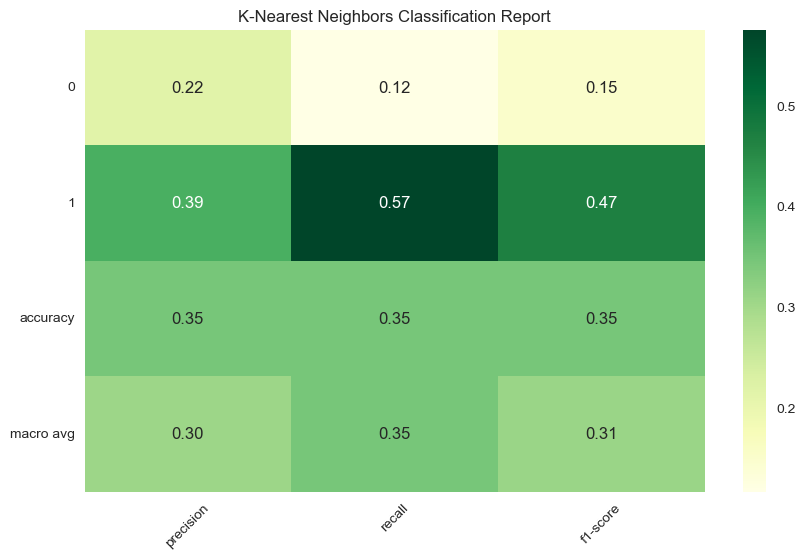

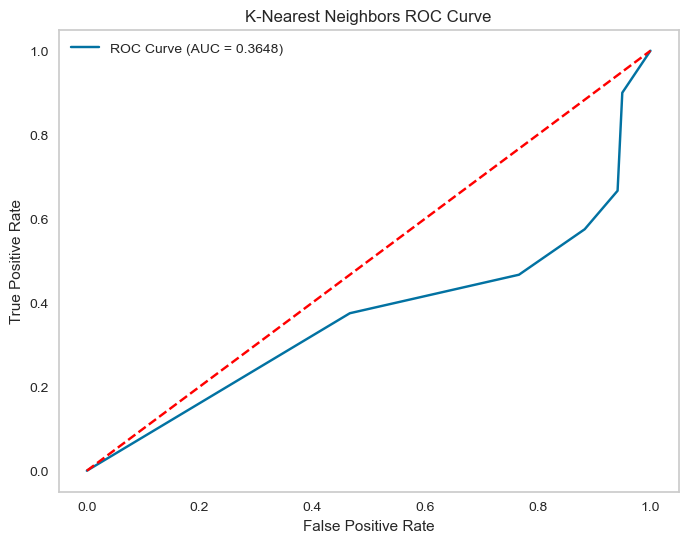

In [29]:
from sklearn.neighbors import KNeighborsClassifier

# KNN Classifier
knn = KNeighborsClassifier(n_neighbors=5)  # Adjust n_neighbors as needed
knn.fit(X_train, y_train)

# Evaluate KNN
knn_metrics = evaluate_model(
    model=knn,
    X=X_scaled_val,
    y=y_validation_encoded,
    label_encoder=label_encoder,
    model_name="K-Nearest Neighbors"
)


accuracy_knn = knn_metrics["accuracy"]
precision_knn = knn_metrics["precision"]
recall_knn = knn_metrics["recall"]
roc_auc_knn = knn_metrics["roc_auc"]
fpr_knn, tpr_knn = knn_metrics["fpr"], knn_metrics["tpr"]

# Models comparison

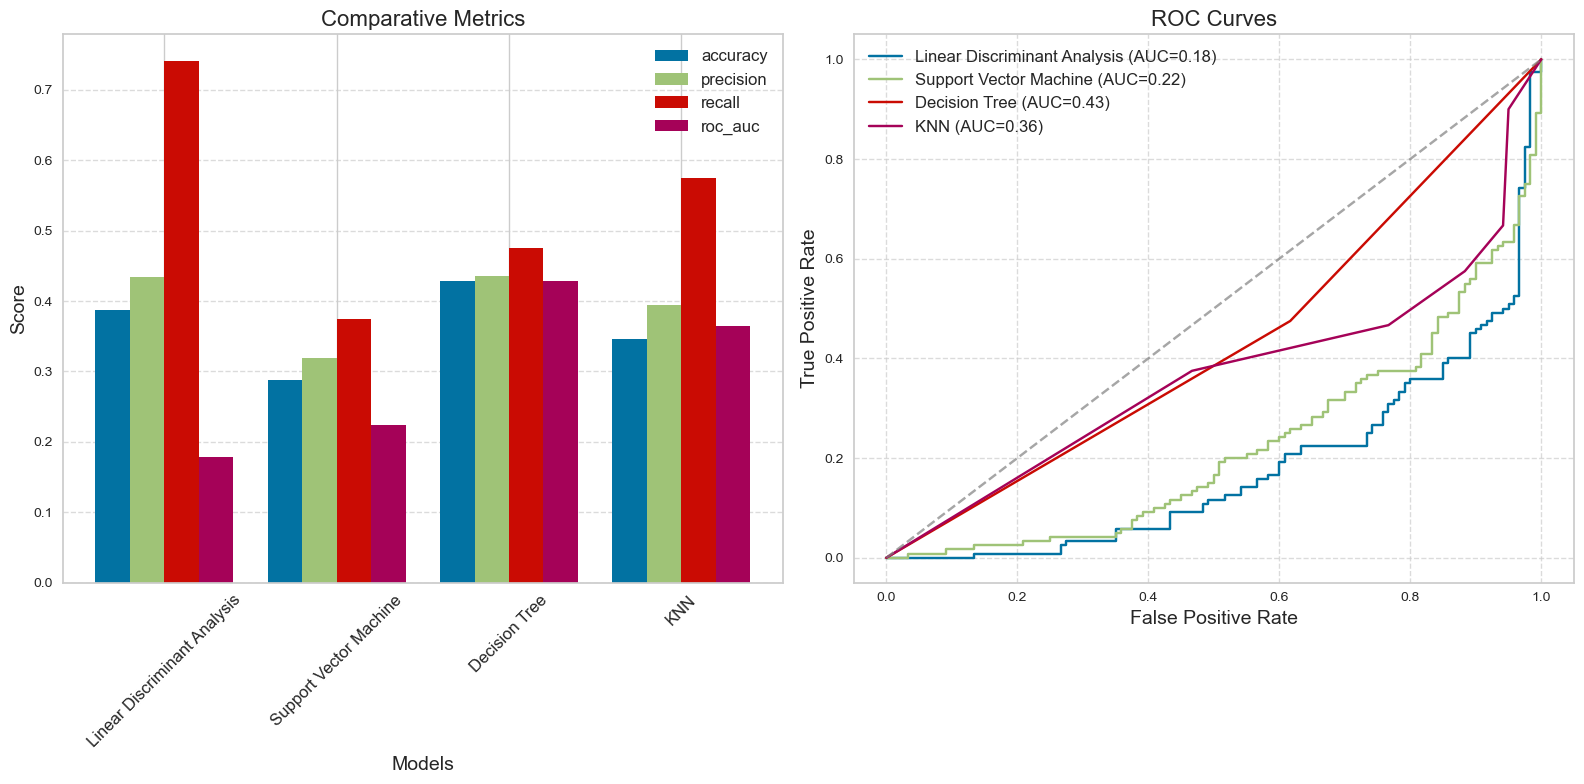


### Numeric Comparison Table ###


,accuracy,precision,recall,roc_auc
Model,,,,
Linear Discriminant Analysis,0.3875,0.434146,0.741667,0.178542
Support Vector Machine,0.2875,0.319149,0.375,0.223542
Decision Tree,0.429167,0.435115,0.475,0.429167
KNN,0.345833,0.394286,0.575,0.364757


In [30]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

def compare_models(metrics_dict, roc_curves, labels):
    """
    Generates improved comparative plots and a metrics table for classification models.
    
    Parameters:
    - metrics_dict: A dictionary with model names as keys and metric dictionaries as values.
    - roc_curves: A dictionary with model names as keys and (fpr, tpr, roc_auc) as values.
    - labels: List of model names.
    """
    # Comparative Metrics
    metrics_to_plot = ['accuracy', 'precision', 'recall', 'roc_auc']
    n_metrics = len(metrics_to_plot)
    
    fig, ax = plt.subplots(1, 2, figsize=(16, 8))
    
    # Grouped bar plot for metrics
    bar_width = 0.2
    x = np.arange(len(labels))
    
    for i, metric in enumerate(metrics_to_plot):
        values = [metrics_dict[label][metric] for label in labels]
        ax[0].bar(x + i * bar_width, values, width=bar_width, label=metric)
    
    ax[0].set_title("Comparative Metrics", fontsize=16)
    ax[0].set_ylabel("Score", fontsize=14)
    ax[0].set_xlabel("Models", fontsize=14)
    ax[0].set_xticks(x + bar_width * (n_metrics - 1) / 2)
    ax[0].set_xticklabels(labels, rotation=45, fontsize=12)
    ax[0].legend(fontsize=12)
    ax[0].grid(axis='y', linestyle='--', alpha=0.7)
    
    # ROC Curves
    for label in labels:
        fpr, tpr, roc_auc = roc_curves[label]
        ax[1].plot(fpr, tpr, label=f"{label} (AUC={roc_auc:.2f})")
    
    ax[1].plot([0, 1], [0, 1], linestyle='--', color='gray', alpha=0.7)
    ax[1].set_title("ROC Curves", fontsize=16)
    ax[1].set_xlabel("False Positive Rate", fontsize=14)
    ax[1].set_ylabel("True Positive Rate", fontsize=14)
    ax[1].legend(fontsize=12)
    ax[1].grid(True, linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    plt.show()
    
    # Create a table for numeric metrics
    metrics_df = pd.DataFrame(metrics_dict).T[metrics_to_plot]
    metrics_df.index.name = "Model"
    
    print("\n### Numeric Comparison Table ###")
    display(metrics_df)  # If using Jupyter Notebook
    # return metrics_df



labels = ["Linear Discriminant Analysis","Support Vector Machine", "Decision Tree", "KNN"]
metrics_dict = {
    "Linear Discriminant Analysis": lda_metrics,
    "Support Vector Machine" : svm_metrics,
    "Decision Tree": dt_metrics,
    "KNN": knn_metrics,
}
roc_curves = {
    "Linear Discriminant Analysis": (fpr_lda, tpr_lda, roc_auc_lda),
    "Support Vector Machine" : (fpr_svm, tpr_svm, roc_auc_svm),
    "Decision Tree": (fpr_dt, tpr_dt, roc_auc_dt),
    "KNN": (fpr_knn, tpr_knn, roc_auc_knn),
}

compare_models(metrics_dict, roc_curves, labels)


# Comparative Analysis

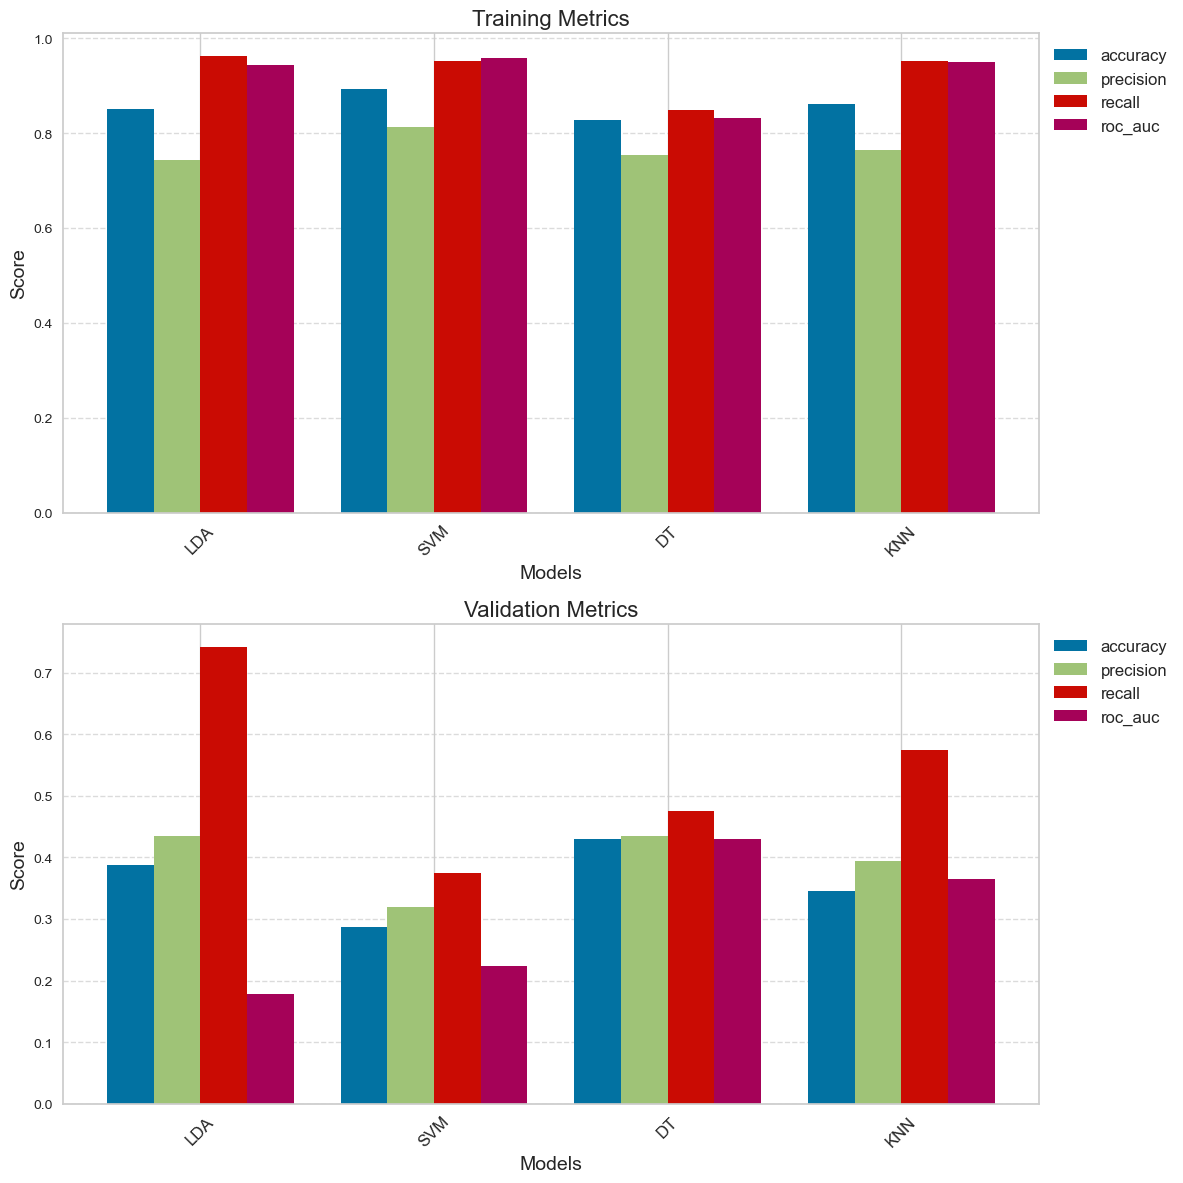

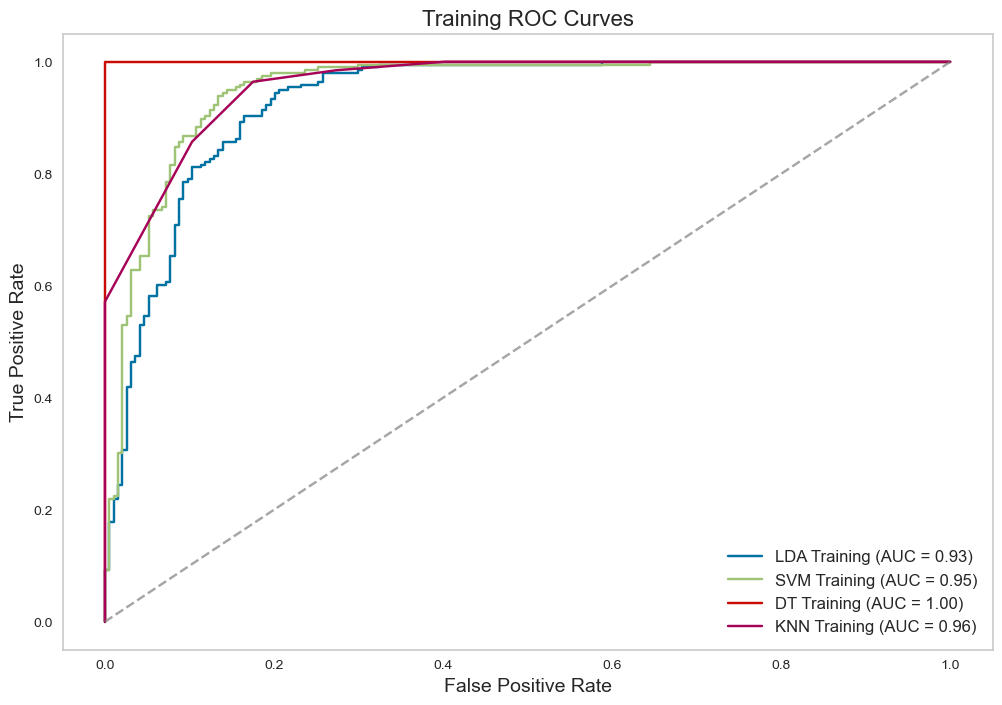

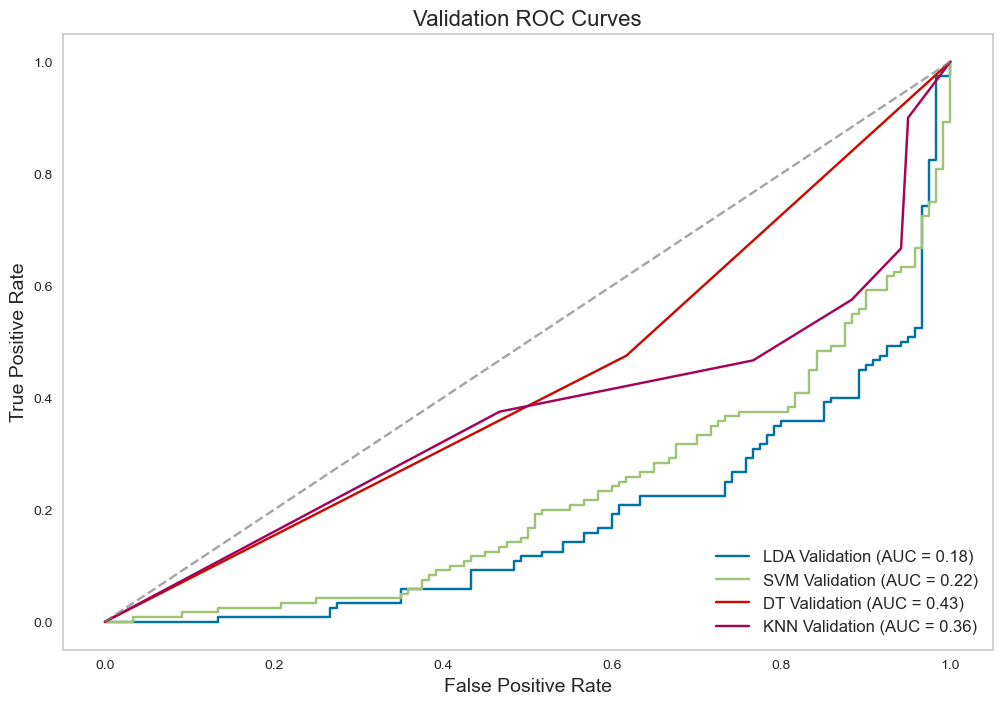

In [33]:
def plot_training_vs_validation_metrics(metrics_dict_validation, metrics_dict_training, labels):
    """
    Generate bar plots comparing training and validation metrics for each model.
    """
    metrics_to_plot = ['accuracy', 'precision', 'recall', 'roc_auc']
    n_metrics = len(metrics_to_plot)
    
    # Separate plots for training and validation
    fig, ax = plt.subplots(2, 1, figsize=(12, 12))
    
    # Training metrics
    bar_width = 0.2
    x = np.arange(len(labels))
    for i, metric in enumerate(metrics_to_plot):
        values_training = [metrics_dict_training[label][metric] for label in labels]
        ax[0].bar(x + i * bar_width, values_training, width=bar_width, label=metric)
    
    ax[0].set_title("Training Metrics", fontsize=16)
    ax[0].set_ylabel("Score", fontsize=14)
    ax[0].set_xlabel("Models", fontsize=14)
    ax[0].set_xticks(x + bar_width * (n_metrics - 1) / 2)
    ax[0].set_xticklabels(labels, rotation=45, fontsize=12)
    ax[0].legend(fontsize=12, loc='upper left', bbox_to_anchor=(1, 1))  # Move legend outside the plot
    ax[0].grid(axis='y', linestyle='--', alpha=0.7)
    
    # Validation metrics
    for i, metric in enumerate(metrics_to_plot):
        values_validation = [metrics_dict_validation[label][metric] for label in labels]
        ax[1].bar(x + i * bar_width, values_validation, width=bar_width, label=metric)
    
    ax[1].set_title("Validation Metrics", fontsize=16)
    ax[1].set_ylabel("Score", fontsize=14)
    ax[1].set_xlabel("Models", fontsize=14)
    ax[1].set_xticks(x + bar_width * (n_metrics - 1) / 2)
    ax[1].set_xticklabels(labels, rotation=45, fontsize=12)
    ax[1].legend(fontsize=12, loc='upper left', bbox_to_anchor=(1, 1))  # Move legend outside the plot
    ax[1].grid(axis='y', linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    plt.show()


def plot_training_vs_validation_roc(roc_curves, labels):
    """
    Generate separate plots for training and validation ROC curves for each model.
    """
    # Training ROC curves
    plt.figure(figsize=(12, 8))
    for label in labels:
        fpr_train, tpr_train, roc_auc_train = roc_curves[label]["training"]
        plt.plot(fpr_train, tpr_train, label=f"{label} Training (AUC = {roc_auc_train:.2f})")
    plt.plot([0, 1], [0, 1], linestyle="--", color="gray", alpha=0.7)
    plt.title("Training ROC Curves", fontsize=16)
    plt.xlabel("False Positive Rate", fontsize=14)
    plt.ylabel("True Positive Rate", fontsize=14)
    plt.legend(fontsize=12, loc='lower right')  # Position legend to avoid overlapping
    plt.grid()
    plt.show()
    
    # Validation ROC curves
    plt.figure(figsize=(12, 8))
    for label in labels:
        fpr_val, tpr_val, roc_auc_val = roc_curves[label]["validation"]
        plt.plot(fpr_val, tpr_val, label=f"{label} Validation (AUC = {roc_auc_val:.2f})")
    plt.plot([0, 1], [0, 1], linestyle="--", color="gray", alpha=0.7)
    plt.title("Validation ROC Curves", fontsize=16)
    plt.xlabel("False Positive Rate", fontsize=14)
    plt.ylabel("True Positive Rate", fontsize=14)
    plt.legend(fontsize=12, loc='lower right')  # Position legend to avoid overlapping
    plt.grid()
    plt.show()

# Generate plots
plot_training_vs_validation_metrics(metrics_dict_validation, metrics_dict_training, labels)
plot_training_vs_validation_roc(roc_curves, labels)


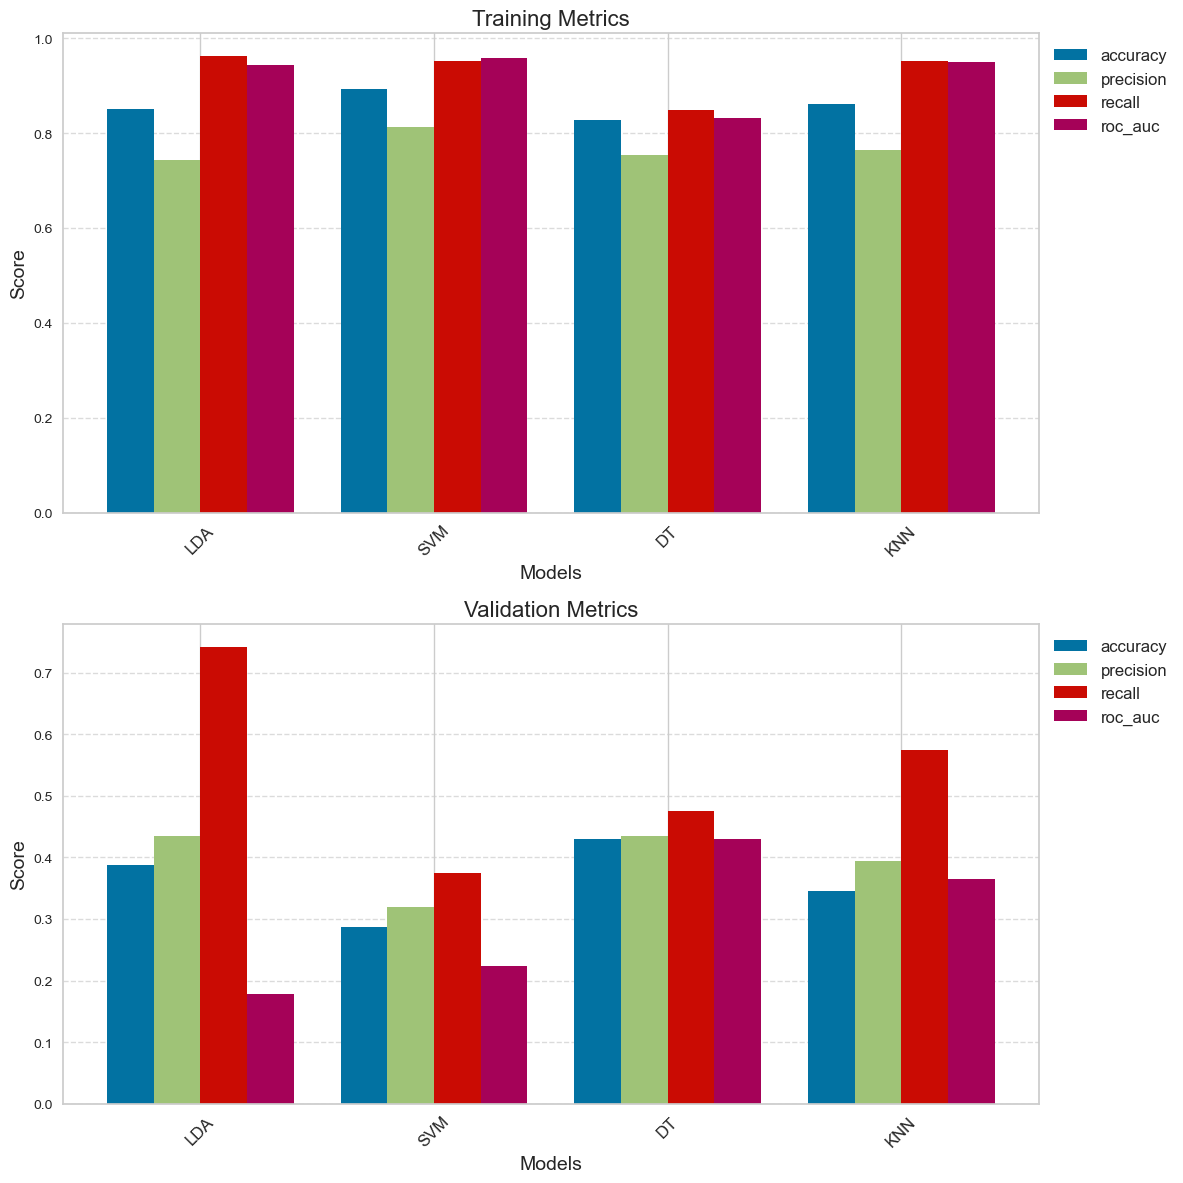

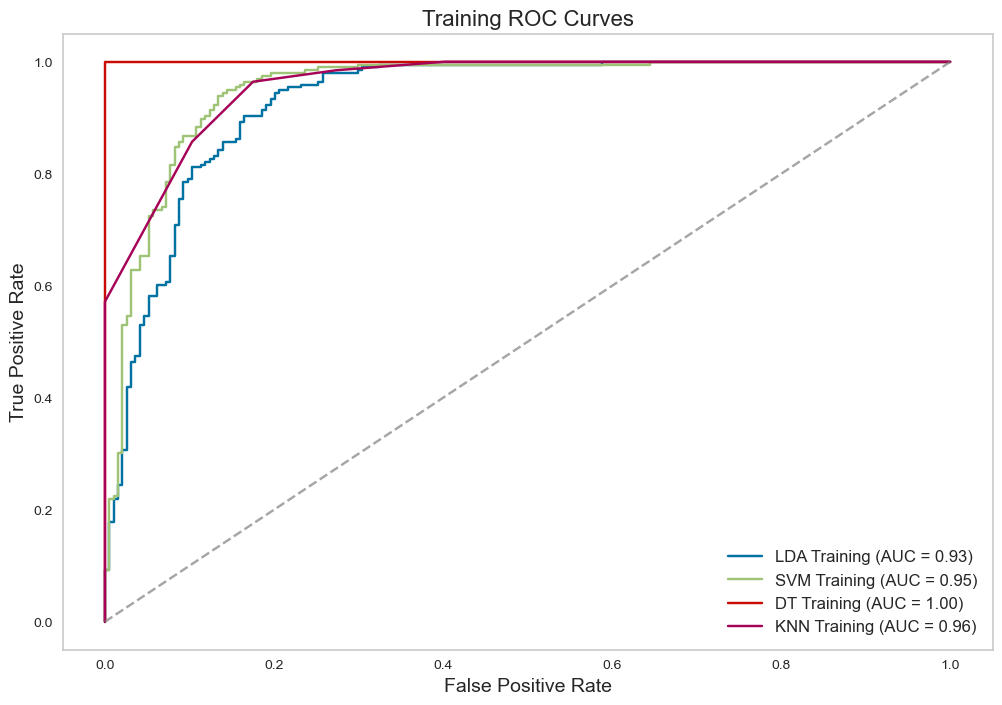

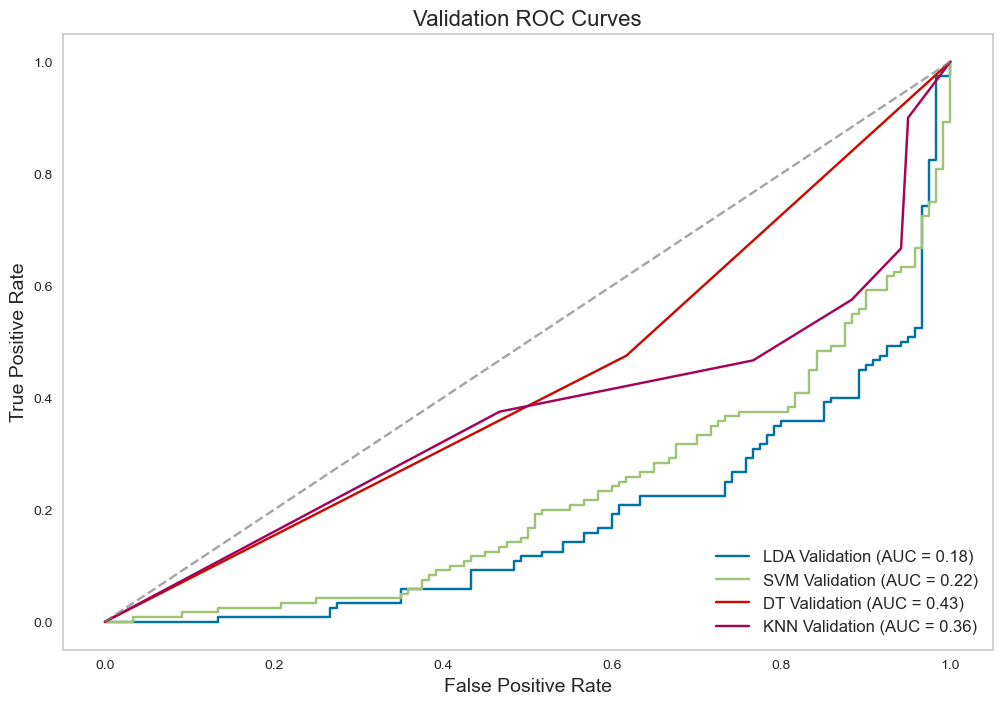

In [34]:
# Labels for the models
labels = ["LDA", "SVM", "DT", "KNN"]

# Training Metrics Dictionary
metrics_dict_training = {
    "LDA": lda_training_metrics,
    "SVM": svm_training_metrics,
    "DT": dt_training_metrics,
    "KNN": knn_training_metrics,
}

# Validation Metrics Dictionary
metrics_dict_validation = {
    "LDA": lda_metrics,
    "SVM": svm_metrics,
    "DT": dt_metrics,
    "KNN": knn_metrics,
}

# ROC Curves Dictionary
roc_curves = {
    "LDA": {
        "training": (fpr_lda_train, tpr_lda_train, roc_auc_lda_train),
        "validation": (fpr_lda, tpr_lda, roc_auc_lda),
    },
    "SVM": {
        "training": (fpr_svm_train, tpr_svm_train, roc_auc_svm_train),
        "validation": (fpr_svm, tpr_svm, roc_auc_svm),
    },
    "DT": {
        "training": (fpr_dt_train, tpr_dt_train, roc_auc_dt_train),
        "validation": (fpr_dt, tpr_dt, roc_auc_dt),
    },
    "KNN": {
        "training": (fpr_knn_train, tpr_knn_train, roc_auc_knn_train),
        "validation": (fpr_knn, tpr_knn, roc_auc_knn),
    },
}

# Generate plots
plot_training_vs_validation_metrics(metrics_dict_validation, metrics_dict_training, labels)
plot_training_vs_validation_roc(roc_curves, labels)


<div class="alert alert-info" role="alert", style="border-radius: 70px">
    <h2 style="text-align: center; margin-top:0.5cm; margin-bottom:0.5cm; font-size:20px">References</h2>
</div>

[1]	Khan J, Bhatti MH, Khan UG, Iqbal R. Multiclass EEG motor-imagery classification with sub-band common spatial patterns. EURASIP J Wirel Commun Netw [Internet]. 2019;2019(1). Available from: http://dx.doi.org/10.1186/s13638-019-1497-y
 	 
[2]	Saibene A, Caglioni M, Corchs S, Gasparini F. EEG-based BCIs on motor imagery paradigm using wearable technologies: A systematic review. Sensors (Basel) [Internet]. 2023;23(5):2798. Available from: https://www.mdpi.com/1424-8220/23/5/2798
 	 
[3]	Wang Y, Gao S, Gao X. Common spatial pattern method for channel selelction in motor imagery based brain-computer interface. In: 2005 IEEE Engineering in Medicine and Biology 27th Annual Conference. IEEE; 2005. p. 5392–5.
 	 
[4]	Omari S, Omari A, Abderrahim M. Multiple tangent space projection for motor imagery EEG classification. Appl Intell [Internet]. 2023;53(18):21192–200. Available from: http://dx.doi.org/10.1007/s10489-023-04551-2
 	 
[5]	Casso M-I, Jeunet C, Roy RN. Heading for motor imagery brain-computer interfaces (MI-BCIs) usable out-of-the-lab: Impact of dry electrode setup on classification accuracy. In: 2021 10th International IEEE/EMBS Conference on Neural Engineering (NER). IEEE; 2021. p. 690–3.
 	 
